# Discrete-metric exploration

This notebook computes  discrete metrics used in `paper_plots no_duration.ipynb` and shows their distributions at every walking speed. A flagged participant-speed trial is excluded for both treadmill models.

In [ ]:
# Configuration
RESULT_PATH = <Path_to_Result_Folder>  # Path to the folder containing the result CSV files.
OUTLIER_PATH = None  # Set to a CSV path when EXCLUDE_OBJECTIVE_OUTLIERS is True.
SPEEDS = [1.0, 1.2, 1.4, 1.6, 1.8]
EXCLUDE_OBJECTIVE_OUTLIERS = False
EXPORT_FIGURE = False

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch

def points_within_boxplot_whiskers(data, value_column, group_columns):
    """Hide point markers beyond 1.5 x IQR without filtering plot distributions."""
    grouped = data.groupby(group_columns)[value_column]
    q1 = grouped.transform(lambda values: values.quantile(0.25))
    q3 = grouped.transform(lambda values: values.quantile(0.75))
    iqr = q3 - q1
    visible = data[value_column].between(q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return data.loc[visible]

trajectory_path = Path(RESULT_PATH).expanduser().resolve()
if not trajectory_path.is_file():
    raise FileNotFoundError(f"Result CSV not found: {trajectory_path}")

result_name = trajectory_path.stem
output_directory = trajectory_path.parent

outlier_trials = pd.DataFrame(columns=["participant", "speed"])
if EXCLUDE_OBJECTIVE_OUTLIERS:
    if OUTLIER_PATH is None:
        raise ValueError("Set OUTLIER_PATH to exclude objective outliers.")
    outlier_path = Path(OUTLIER_PATH).expanduser().resolve()
    outlier_rows = pd.read_csv(outlier_path)
    exclusion_column = (
        "exclude_pair" if "exclude_pair" in outlier_rows.columns
        else "objective_outlier"
    )
    if exclusion_column in outlier_rows.columns:
        is_outlier = (
            outlier_rows[exclusion_column].eq(True)
            | outlier_rows[exclusion_column].astype(str).str.lower().eq("true")
        )
        outlier_rows = outlier_rows.loc[is_outlier]
    outlier_trials = outlier_rows[["participant", "speed"]].drop_duplicates()

print(f"Participant-speed trials excluded from both models: {len(outlier_trials)}")
outlier_trials.sort_values(["participant", "speed"])

Participant-speed trials excluded from both models: 0


,participant,speed


In [3]:
df = pd.read_csv(trajectory_path)
excluded_index = pd.MultiIndex.from_frame(outlier_trials)
trial_index = pd.MultiIndex.from_frame(df[["participant", "speed"]])
df = df.loc[~trial_index.isin(excluded_index)].copy()
df = df.set_index(["participant", "speed", "treadmill_model", "node"]).sort_index()

def peak_moment(trajectory):
    return trajectory.max()

def peak_hip_extension_moment(trajectory):
    # Hip flexion is positive in the model convention; report the negative extension peak as a magnitude.
    return -trajectory.min()

def rom(trajectory):
    return trajectory.max() - trajectory.min()

metric_rows = []
for (participant, speed, model), trial in df.groupby(
    level=["participant", "speed", "treadmill_model"]
):
    metric_rows.append({
        "participant": participant,
        "speed": speed,
        "treadmill_model": model,
        "metabolic_rate_w_per_kg": trial["metabolic_rate_w_per_kg"].iloc[0],
        "hip_peak_moment": peak_hip_extension_moment(trial["M_hip_r_nm_per_kg"]),
        "knee_peak_moment": peak_moment(trial["M_knee_r_nm_per_kg"]),
        "ankle_peak_moment": peak_moment(trial["M_ankle_r_nm_per_kg"]),
        "hip_rom": rom(trial["q_hip_r_deg"]),
        "ankle_rom": rom(trial["q_ankle_r_deg"]),
        "cadence_steps_per_min": trial["cadence_steps_per_min"].iloc[0],
        "step_length_m": trial["step_length_m"].iloc[0],
    })

metrics_df = pd.DataFrame(metric_rows).sort_values(
    ["participant", "speed", "treadmill_model"]
).reset_index(drop=True)
metrics_df

,participant,speed,treadmill_model,metabolic_rate_w_per_kg,hip_peak_moment,knee_peak_moment,ankle_peak_moment,hip_rom,ankle_rom,cadence_steps_per_min,step_length_m
0,P1,1.0,ideal,2.329098,-0.201817,0.223203,-0.205579,38.247883,30.546865,99.719837,0.601686
1,P1,1.0,real,2.390593,-0.207437,0.226762,-0.205252,38.244289,30.624928,99.823570,0.601060
2,P1,1.2,ideal,2.849741,-0.221982,0.281044,-0.215717,41.197027,31.746191,110.280663,0.652880
3,P1,1.2,real,2.854735,-0.269363,0.252370,-0.206932,41.134611,31.714599,110.709131,0.650353
4,P1,1.4,ideal,3.414178,-0.309347,0.352469,-0.216195,42.657108,32.610368,122.421666,0.686153
...,...,...,...,...,...,...,...,...,...,...,...
137,P9,1.4,real,3.470080,-0.290165,0.385668,-0.219349,42.322050,32.304804,123.339489,0.681047
138,P9,1.6,ideal,4.439559,-0.453496,0.368462,-0.211837,44.529275,33.896154,137.065053,0.700397
139,P9,1.6,real,4.378225,-0.456279,0.371397,-0.212245,44.423675,34.151824,137.045357,0.700498
140,P9,1.8,ideal,5.193555,-0.369297,0.553660,-0.273478,44.248766,33.474820,148.593703,0.726814


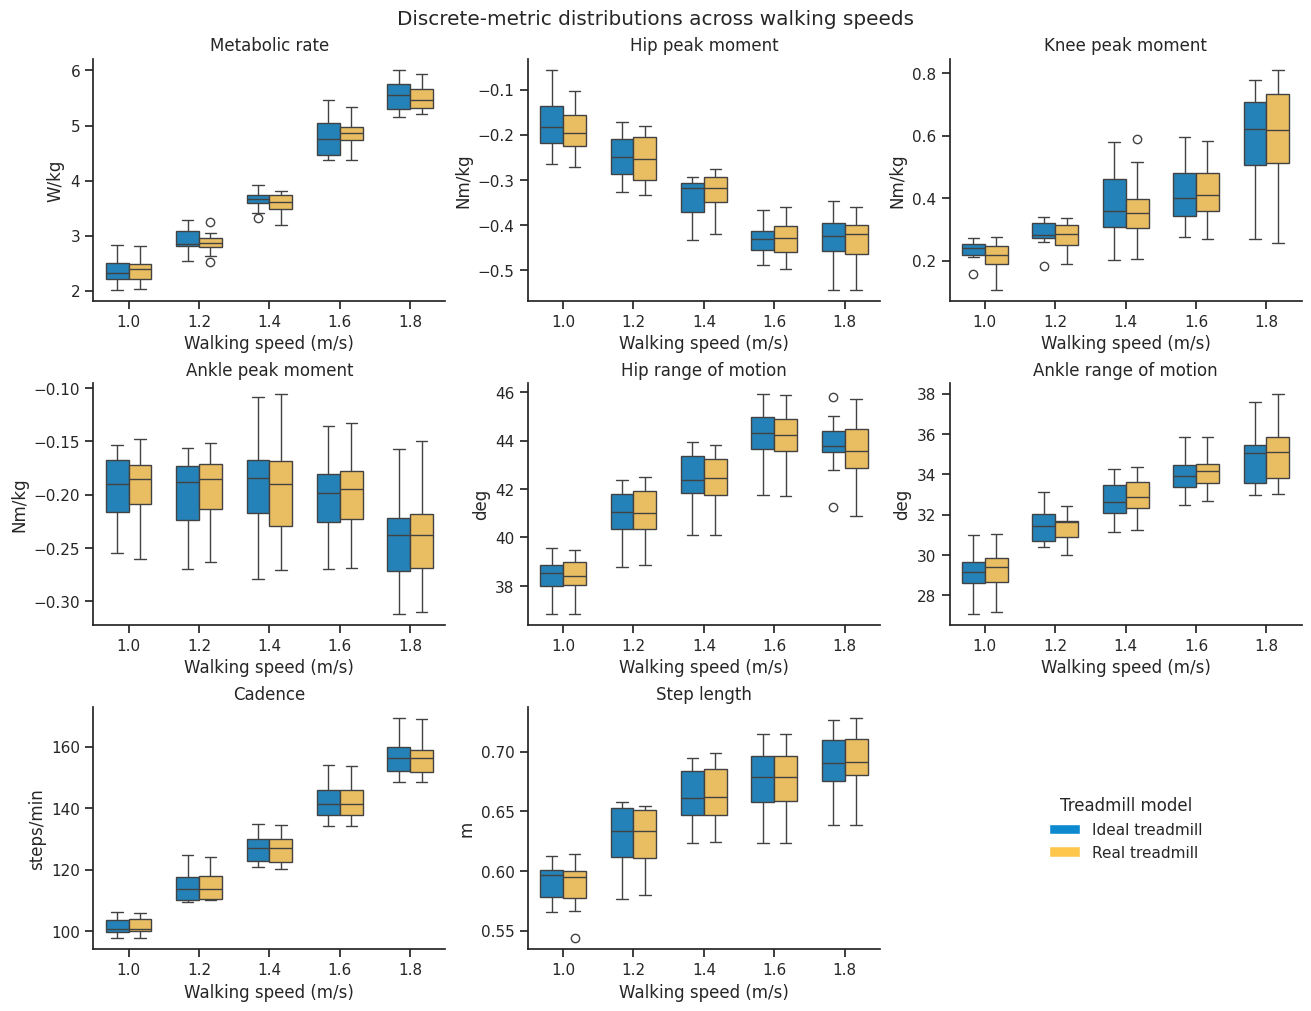

In [4]:
metric_specs = [
    ("metabolic_rate_w_per_kg", "Metabolic rate", "W/kg"),
    ("hip_peak_moment", "Hip peak moment", "Nm/kg"),
    ("knee_peak_moment", "Knee peak moment", "Nm/kg"),
    ("ankle_peak_moment", "Ankle peak moment", "Nm/kg"),
    ("hip_rom", "Hip range of motion", "deg"),
    ("ankle_rom", "Ankle range of motion", "deg"),
    ("cadence_steps_per_min", "Cadence", "steps/min"),
    ("step_length_m", "Step length", "m"),
]
model_order = ["ideal", "real"]
model_palette = {"ideal": "#0D89D0", "real": "#FFC64C"}
sns.set_theme(style="ticks")

fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
for ax, (column, title, ylabel) in zip(axes.flat, metric_specs):
    sns.boxplot(
        data=points_within_boxplot_whiskers(metrics_df, column, ["speed", "treadmill_model"]), x="speed", y=column, hue="treadmill_model",
        order=SPEEDS, hue_order=model_order, palette=model_palette,
        width=0.65, showfliers=True, ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Walking speed (m/s)")
    ax.set_ylabel(ylabel)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

legend_axis = axes.flat[-1]
legend_axis.axis("off")
legend_axis.legend(
    handles=[Patch(facecolor=model_palette[model], label=f"{model.title()} treadmill") for model in model_order],
    title="Treadmill model", loc="center", frameon=False,
)
fig.suptitle("Discrete-metric distributions across walking speeds")
sns.despine(fig=fig)

if EXPORT_FIGURE:
    output_path = output_directory / f"discrete_metrics_exploration_{result_name}.pdf"
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")

plt.show()

In [5]:
# Combined distribution and descriptive linear trend for ideal - real differences.
"""Misplaced copy retained as a non-executing string; the working cell is at the end.
fig_violin_trend, violin_trend_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (metric, title, ylabel) in zip(violin_trend_axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.violinplot(
        data=plot_data, x="speed", y="difference", hue="speed",
        order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
        inner=None, cut=0, density_norm="width", linewidth=0.8,
        saturation=0.65, alpha=0.35, legend=False, ax=ax,
    )
    sns.stripplot(
        data=points_within_boxplot_whiskers(plot_data, "difference", ["speed"]), x="speed", y="difference",
        order=SPEEDS, jitter=0.14, color="0.15",
        size=4.5, alpha=0.8, edgecolor="white", linewidth=0.4,
        zorder=5, ax=ax,
    )
    sns.regplot(
        data=plot_data, x="speed_position", y="difference",
        scatter=False, ci=None, truncate=True,
        color="crimson", line_kws={"linewidth": 2.5}, ax=ax,
    )
    ax.axhline(0, color="0.35", linewidth=1)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)

violin_trend_axes.flat[-1].axis("off")
violin_trend_axes.flat[-1].plot(
    [], [], color="crimson", linewidth=2.5, label="Descriptive linear trend",
)
violin_trend_axes.flat[-1].legend(loc="center", frameon=False)
fig_violin_trend.suptitle(
    "Paired differences: distributions, observations, and descriptive trends"
)
sns.despine(fig=fig_violin_trend)
"""
plt.show()

In [6]:
# Mixed-effects predictions: value ~ treadmill model * speed + participant random intercept.
import warnings

import numpy as np
import statsmodels.formula.api as smf
from patsy import build_design_matrices

prediction_speeds = np.linspace(min(SPEEDS), max(SPEEDS), 101)
mixed_model_fits = {}
mixed_model_predictions = {}
fixed_effect_rows = []

for column, title, ylabel in metric_specs:
    model_data = metrics_df[["participant", "speed", "treadmill_model", column]].copy()
    model_data = model_data.rename(columns={column: "value"})
    model_data["speed_c"] = model_data["speed"] - model_data["speed"].mean()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = smf.mixedlm(
            "value ~ speed_c * C(treadmill_model, Treatment(reference='real'))",
            data=model_data, groups=model_data["participant"],
        ).fit(reml=False, method="powell")
    mixed_model_fits[column] = fit

    prediction_data = pd.DataFrame({
        "speed": np.tile(prediction_speeds, 2),
        "treadmill_model": np.repeat(["ideal", "real"], len(prediction_speeds)),
    })
    prediction_data["speed_c"] = prediction_data["speed"] - model_data["speed"].mean()
    design = np.asarray(build_design_matrices(
        [fit.model.data.design_info], prediction_data, return_type="dataframe"
    )[0])
    fixed_names = list(fit.fe_params.index)
    fixed_covariance = fit.cov_params().loc[fixed_names, fixed_names].to_numpy()
    prediction_data["predicted"] = design @ fit.fe_params.to_numpy()
    prediction_data["se"] = np.sqrt(np.einsum(
        "ij,jk,ik->i", design, fixed_covariance, design
    ))
    prediction_data["lower"] = prediction_data["predicted"] - 1.96 * prediction_data["se"]
    prediction_data["upper"] = prediction_data["predicted"] + 1.96 * prediction_data["se"]
    mixed_model_predictions[column] = prediction_data

    for term, estimate in fit.fe_params.items():
        fixed_effect_rows.append({
            "metric": column, "term": term, "estimate": estimate,
            "standard_error": fit.bse_fe[term], "p_value": fit.pvalues[term],
        })

mixed_effects_table = pd.DataFrame(fixed_effect_rows)
mixed_effects_table

,metric,term,estimate,standard_error,p_value
0,metabolic_rate_w_per_kg,Intercept,3.798062,0.152455,5.421991e-137
1,metabolic_rate_w_per_kg,"C(treadmill_model, Treatment(reference='real')...",0.257494,0.214082,2.290593e-01
2,metabolic_rate_w_per_kg,speed_c,4.156902,0.533444,6.566105e-15
3,metabolic_rate_w_per_kg,"speed_c:C(treadmill_model, Treatment(reference...",0.546440,0.753045,4.680586e-01
4,hip_peak_moment,Intercept,-0.328427,0.009994,7.683714e-237
5,hip_peak_moment,"C(treadmill_model, Treatment(reference='real')...",0.002619,0.009167,7.751367e-01
6,hip_peak_moment,speed_c,-0.344995,0.022890,2.487294e-51
7,hip_peak_moment,"speed_c:C(treadmill_model, Treatment(reference...",-0.005735,0.032258,8.588921e-01
8,knee_peak_moment,Intercept,0.390536,0.027208,1.008719e-46
9,knee_peak_moment,"C(treadmill_model, Treatment(reference='real')...",-0.000867,0.013478,9.486997e-01


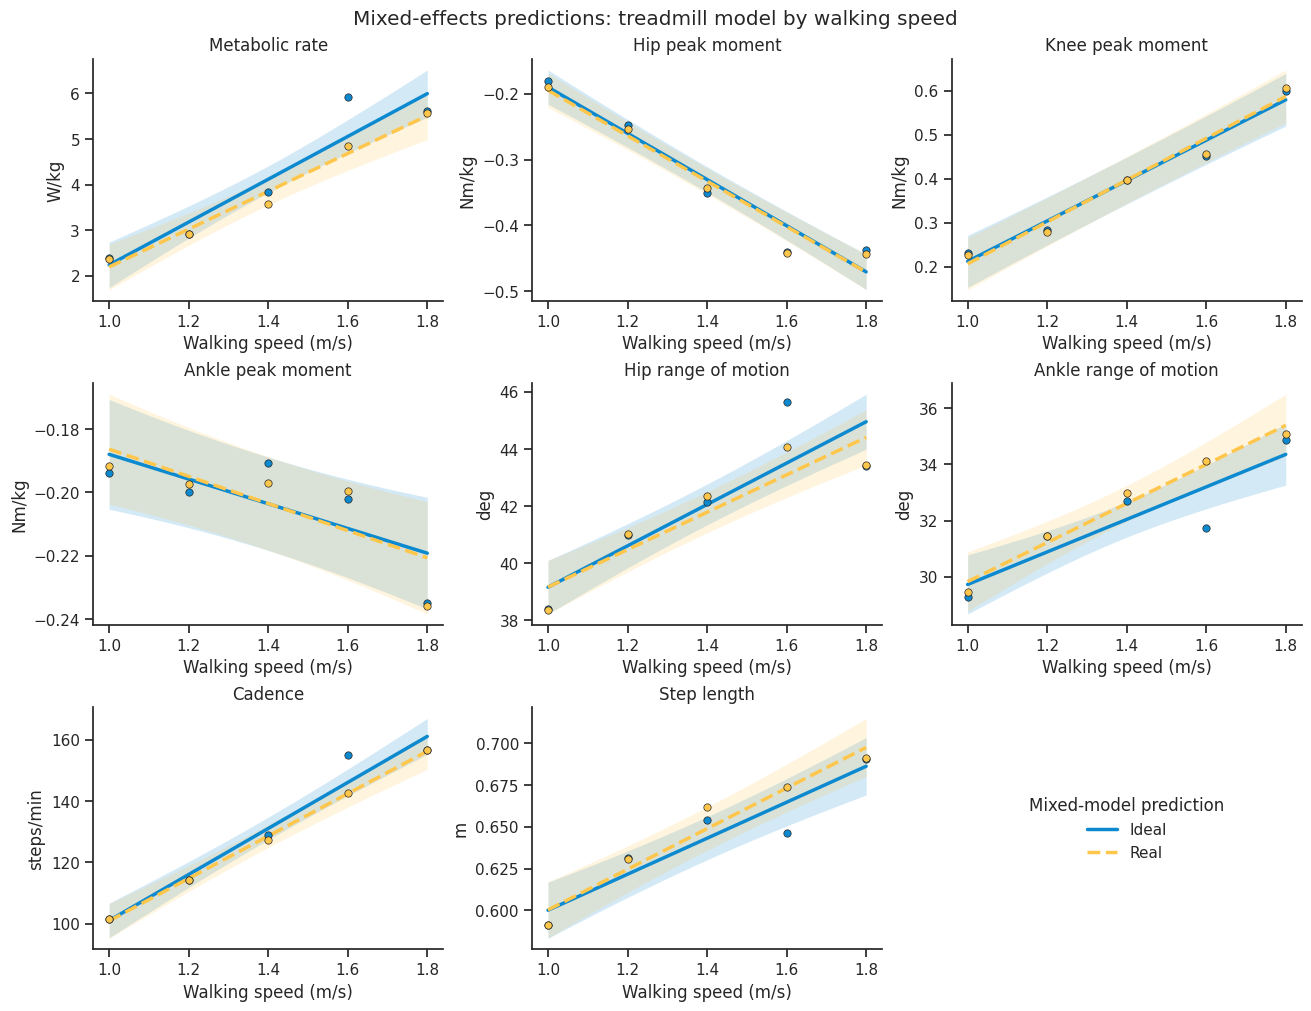

In [7]:
# Model-predicted ideal and real trends with fixed-effect 95% confidence bands.
fig_mixed_predictions, prediction_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (column, title, ylabel) in zip(prediction_axes.flat, metric_specs):
    predictions = mixed_model_predictions[column]
    for model, linestyle in [("ideal", "-"), ("real", "--")]:
        model_predictions = predictions[predictions["treadmill_model"] == model]
        color = model_palette[model]
        ax.plot(
            model_predictions["speed"], model_predictions["predicted"],
            color=color, linestyle=linestyle, linewidth=2.5, label=model.title(),
        )
        ax.fill_between(
            model_predictions["speed"], model_predictions["lower"], model_predictions["upper"],
            color=color, alpha=0.18, linewidth=0,
        )
        observed = metrics_df[metrics_df["treadmill_model"] == model]
        observed_means = observed.groupby("speed")[column].mean().reindex(SPEEDS)
        ax.scatter(
            SPEEDS, observed_means, color=color, edgecolor="0.15",
            linewidth=0.5, s=28, zorder=5,
        )
    ax.set_xticks(SPEEDS)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

prediction_axes.flat[-1].axis("off")
prediction_axes.flat[-1].plot([], [], color=model_palette["ideal"], linewidth=2.5, label="Ideal")
prediction_axes.flat[-1].plot(
    [], [], color=model_palette["real"], linestyle="--", linewidth=2.5, label="Real",
)
prediction_axes.flat[-1].legend(title="Mixed-model prediction", loc="center", frameon=False)
fig_mixed_predictions.suptitle(
    "Mixed-effects predictions: treadmill model by walking speed"
)
sns.despine(fig=fig_mixed_predictions)
plt.show()

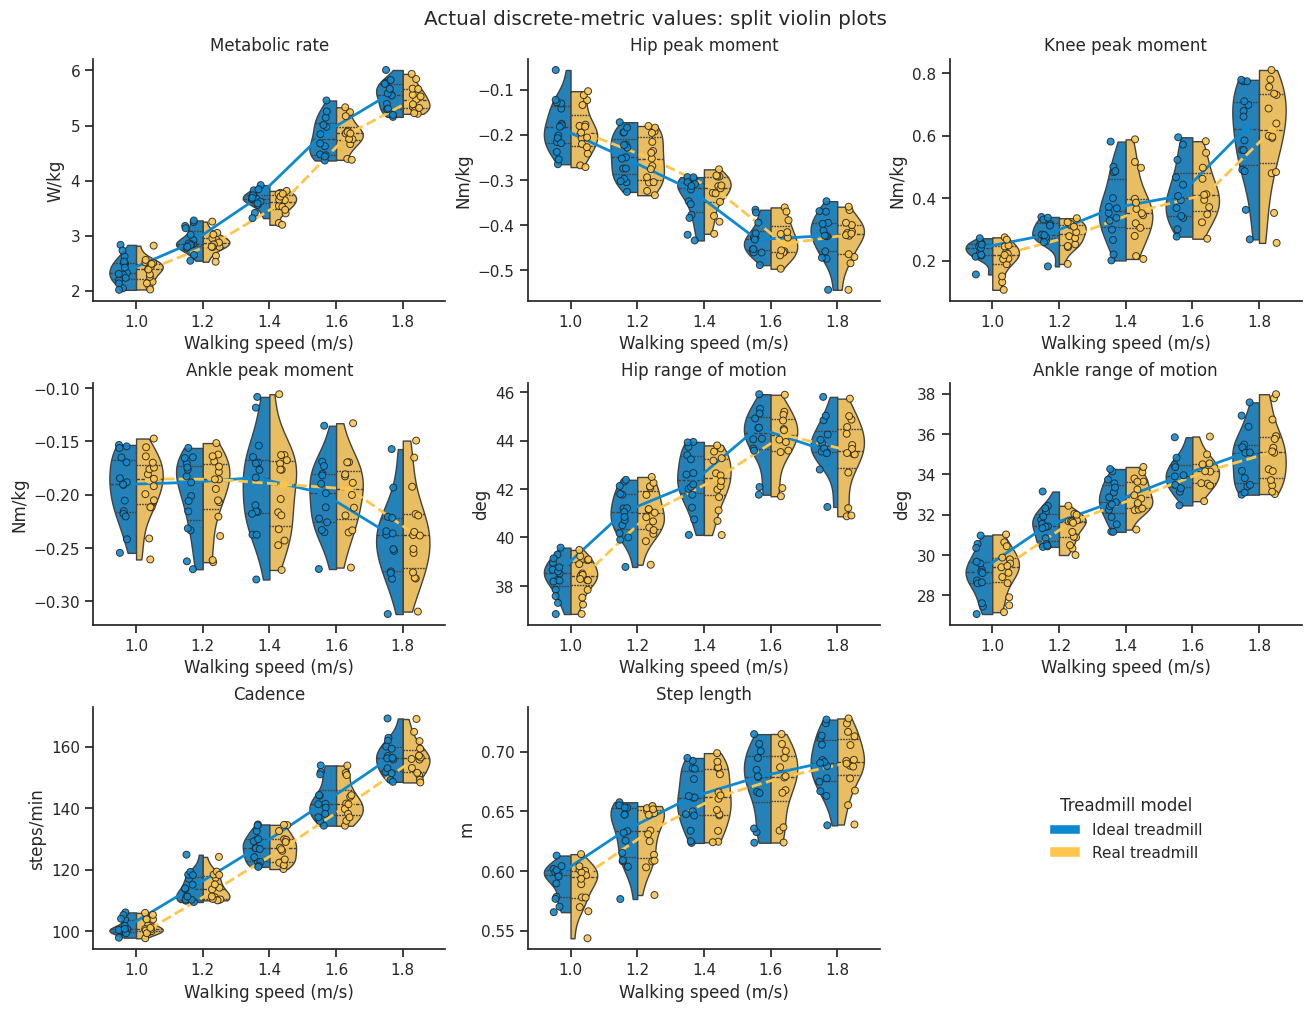

In [8]:
# Actual values as grouped split violins.
fig_actual_violin, actual_violin_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (column, title, ylabel) in zip(actual_violin_axes.flat, metric_specs):
    sns.violinplot(
        data=points_within_boxplot_whiskers(metrics_df, column, ["speed", "treadmill_model"]), x="speed", y=column, hue="treadmill_model",
        order=SPEEDS, hue_order=model_order, palette=model_palette,
        split=True, inner="quart", cut=0, density_norm="width",
        linewidth=1, ax=ax,
    )
    sns.stripplot(
        data=points_within_boxplot_whiskers(metrics_df, column, ["speed", "treadmill_model"]), x="speed", y=column, hue="treadmill_model",
        order=SPEEDS, hue_order=model_order, palette=model_palette,
        dodge=True, jitter=0.14, size=5, alpha=0.9,
        edgecolor="0.15", linewidth=0.7, legend=False, zorder=6, ax=ax,
    )
    for model, offset, linestyle in [("ideal", -0.2, "-"), ("real", 0.2, "--")]:
        medians = (
            metrics_df[metrics_df["treadmill_model"] == model]
            .groupby("speed")[column].median().reindex(SPEEDS)
        )
        ax.plot(
            [position + offset for position in range(len(SPEEDS))], medians,
            color=model_palette[model], linestyle=linestyle,
            marker="o", linewidth=2, markersize=5, zorder=5,
        )
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)
    if ax.get_legend() is not None:
        ax.get_legend().remove()
actual_violin_axes.flat[-1].axis("off")
actual_violin_axes.flat[-1].legend(
    handles=[Patch(facecolor=model_palette[model], label=f"{model.title()} treadmill") for model in model_order],
    title="Treadmill model", loc="center", frameon=False,
)
fig_actual_violin.suptitle("Actual discrete-metric values: split violin plots")
sns.despine(fig=fig_actual_violin)
plt.show()

In [9]:
# Pair ideal and real within participant and speed.
metric_columns = [column for column, _, _ in metric_specs]
long_metrics = metrics_df.melt(
    id_vars=["participant", "speed", "treadmill_model"],
    value_vars=metric_columns, var_name="metric", value_name="value",
)
paired_df = long_metrics.pivot_table(
    index=["participant", "speed", "metric"],
    columns="treadmill_model", values="value",
).reset_index()
paired_df["difference"] = paired_df["ideal"] - paired_df["real"]
relative_metrics = ["cadence_steps_per_min", "step_length_m"]
relative_rows = paired_df["metric"].isin(relative_metrics)
paired_df.loc[relative_rows, "difference"] = (
    paired_df.loc[relative_rows, "ideal"]
    - paired_df.loc[relative_rows, "real"]
) / paired_df.loc[relative_rows, "ideal"] * 100
paired_df["speed_position"] = paired_df["speed"].map(
    {speed: position for position, speed in enumerate(SPEEDS)}
)
difference_specs = [
    ("metabolic_rate_w_per_kg", "Metabolic rate", "Ideal - real (W/kg)"),
    ("hip_peak_moment", "Hip peak moment", "Ideal - real (Nm/kg)"),
    ("knee_peak_moment", "Knee peak moment", "Ideal - real (Nm/kg)"),
    ("ankle_peak_moment", "Ankle peak moment", "Ideal - real (Nm/kg)"),
    ("hip_rom", "Hip range of motion", "Ideal - real (deg)"),
    ("ankle_rom", "Ankle range of motion", "Ideal - real (deg)"),
    ("cadence_steps_per_min", "Cadence", "Ideal - real (%)"),
    ("step_length_m", "Step length", "Ideal - real (%)"),
]
speed_palette = dict(zip(SPEEDS, sns.color_palette("YlOrBr", len(SPEEDS))))
paired_df

treadmill_model,participant,speed,metric,ideal,real,difference,speed_position
0,P1,1.0,ankle_peak_moment,-0.205579,-0.205252,-0.000327,0
1,P1,1.0,ankle_rom,30.546865,30.624928,-0.078063,0
2,P1,1.0,cadence_steps_per_min,99.719837,99.823570,-0.104025,0
3,P1,1.0,hip_peak_moment,-0.201817,-0.207437,0.005620,0
4,P1,1.0,hip_rom,38.247883,38.244289,0.003594,0
...,...,...,...,...,...,...,...
571,P9,1.8,hip_peak_moment,-0.369297,-0.359544,-0.009752,4
572,P9,1.8,hip_rom,44.248766,44.278697,-0.029932,4
573,P9,1.8,knee_peak_moment,0.553660,0.596152,-0.042493,4
574,P9,1.8,metabolic_rate_w_per_kg,5.193555,5.224745,-0.031190,4


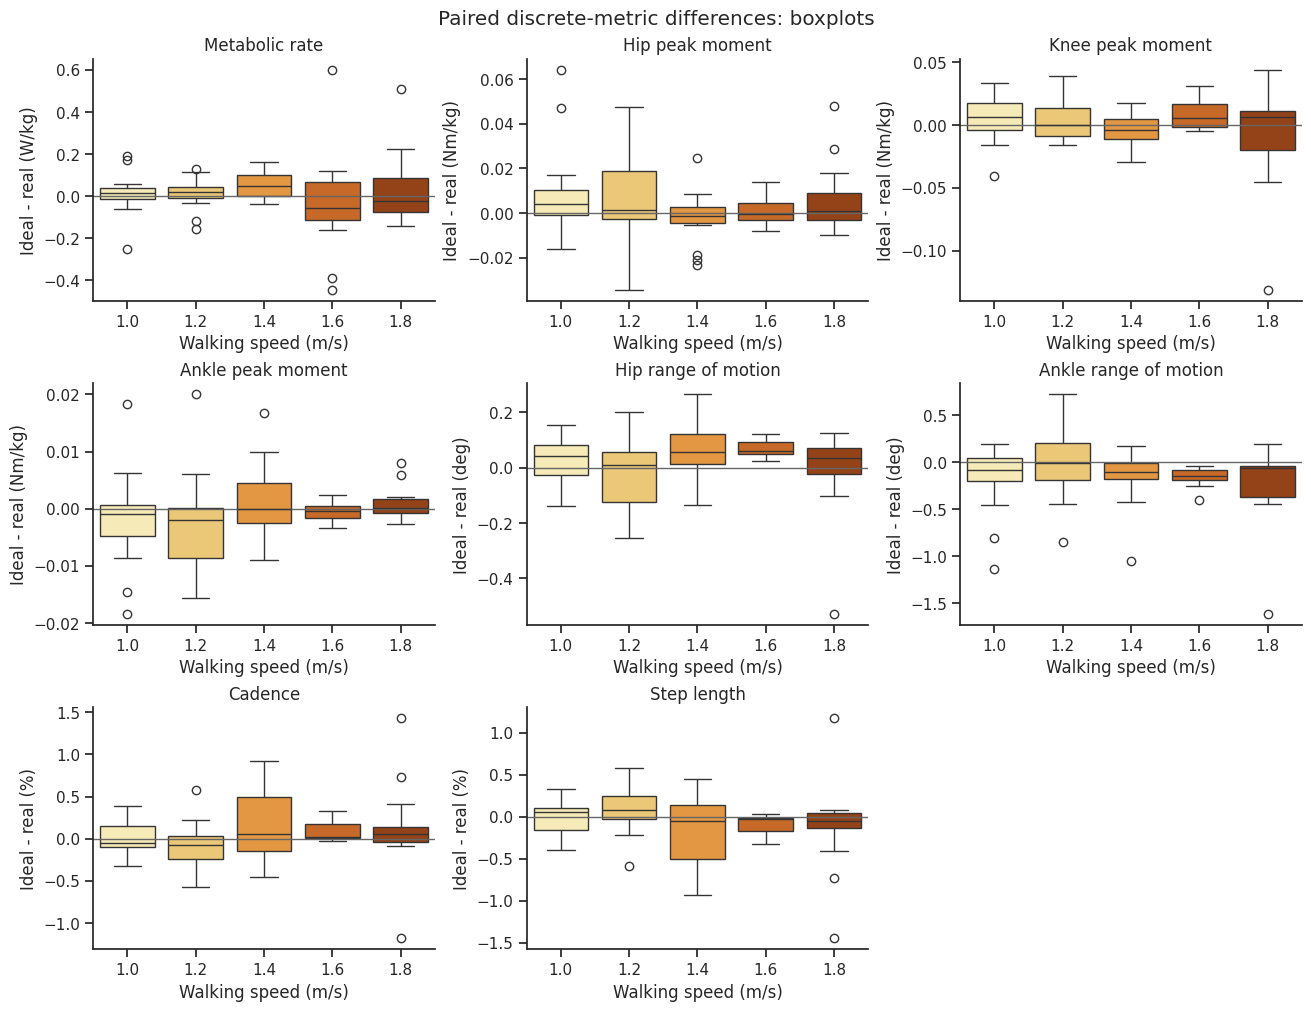

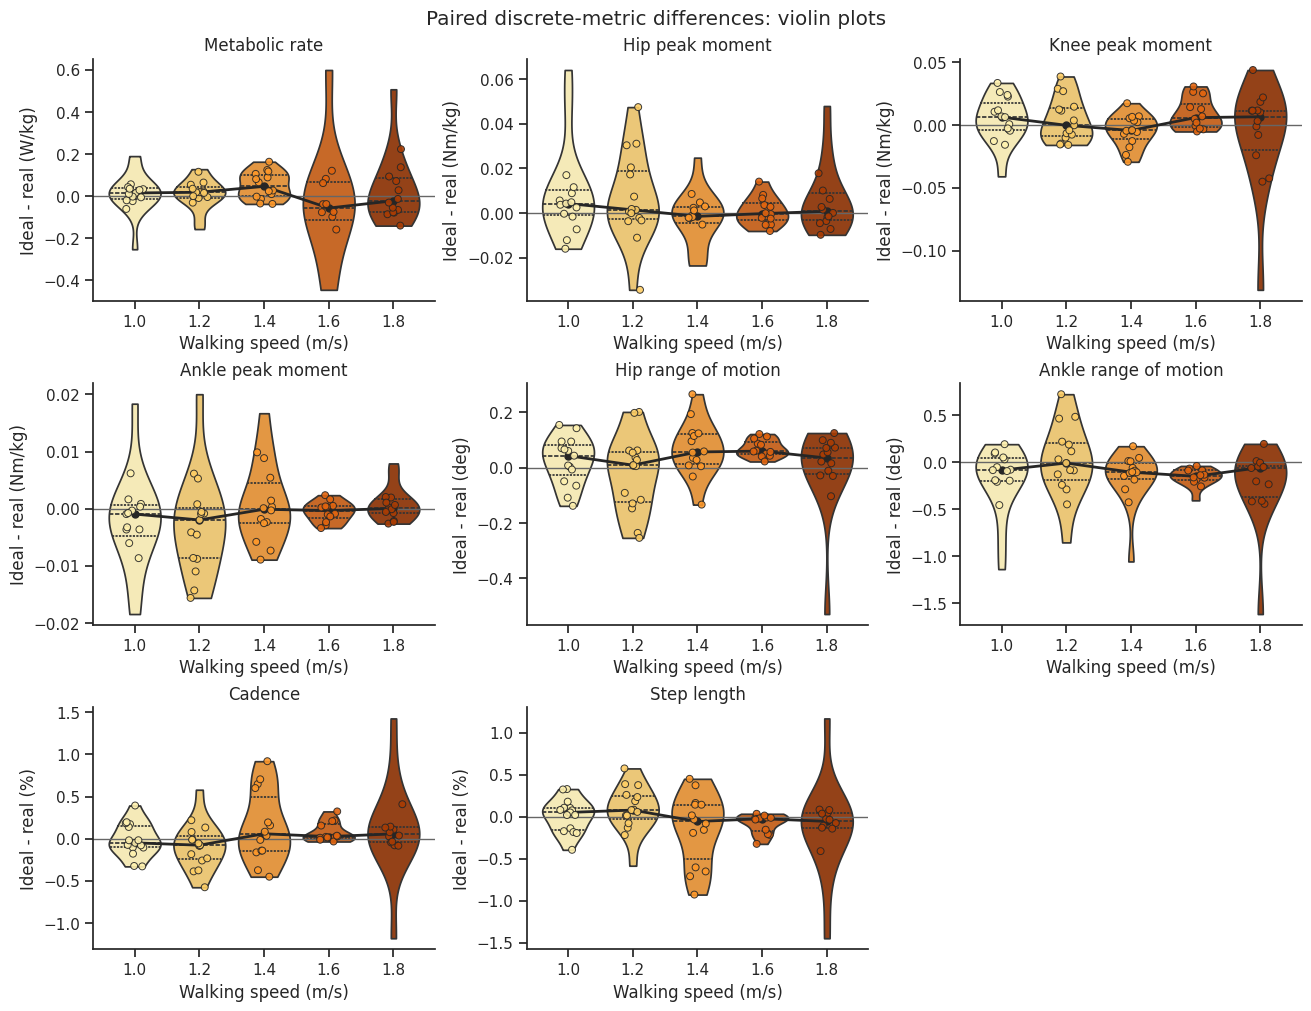

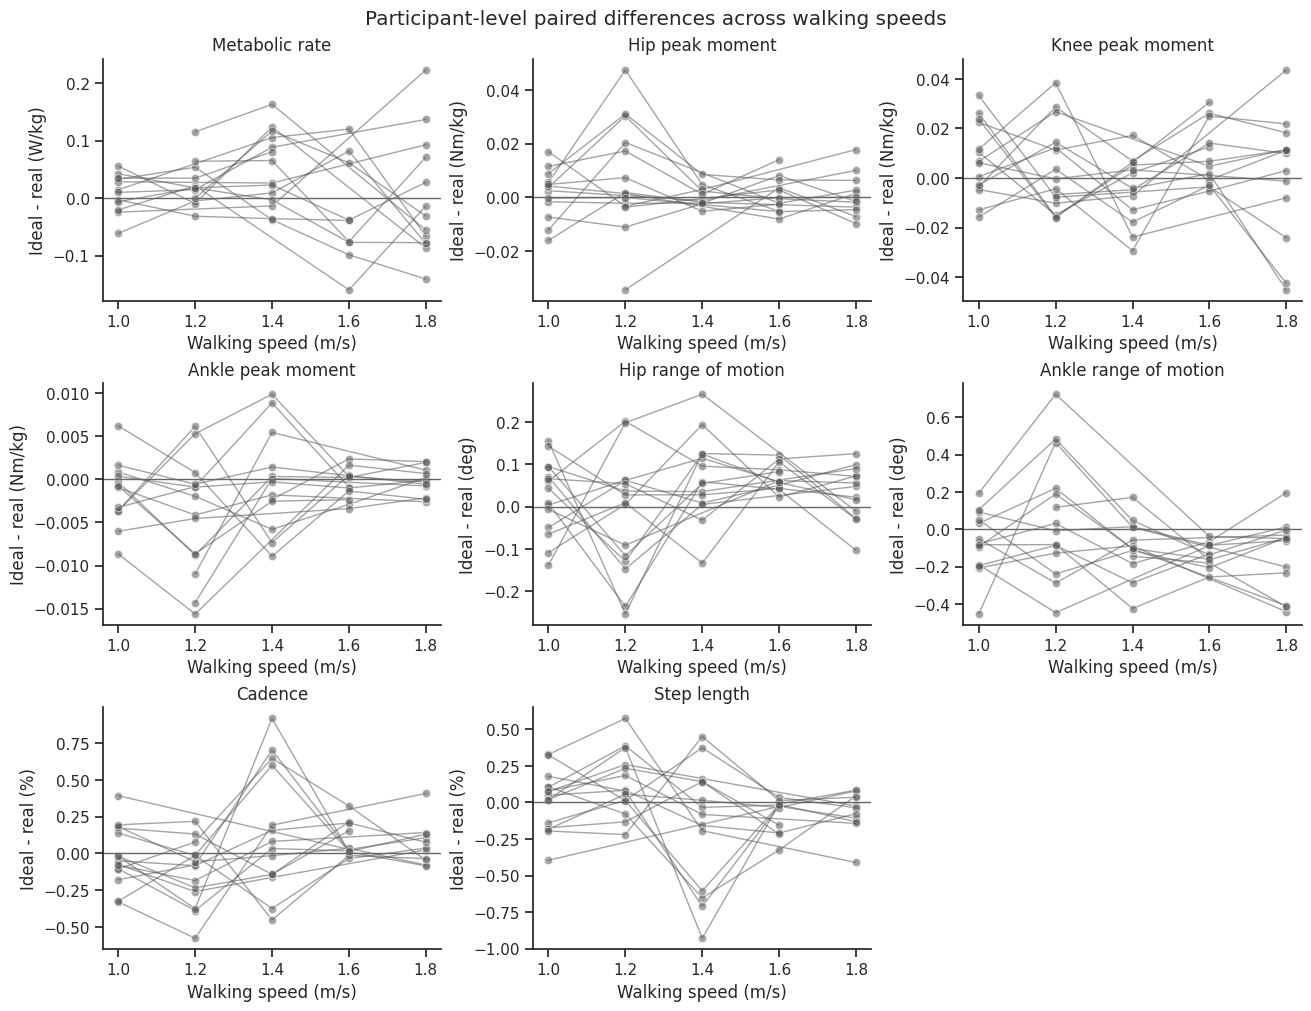

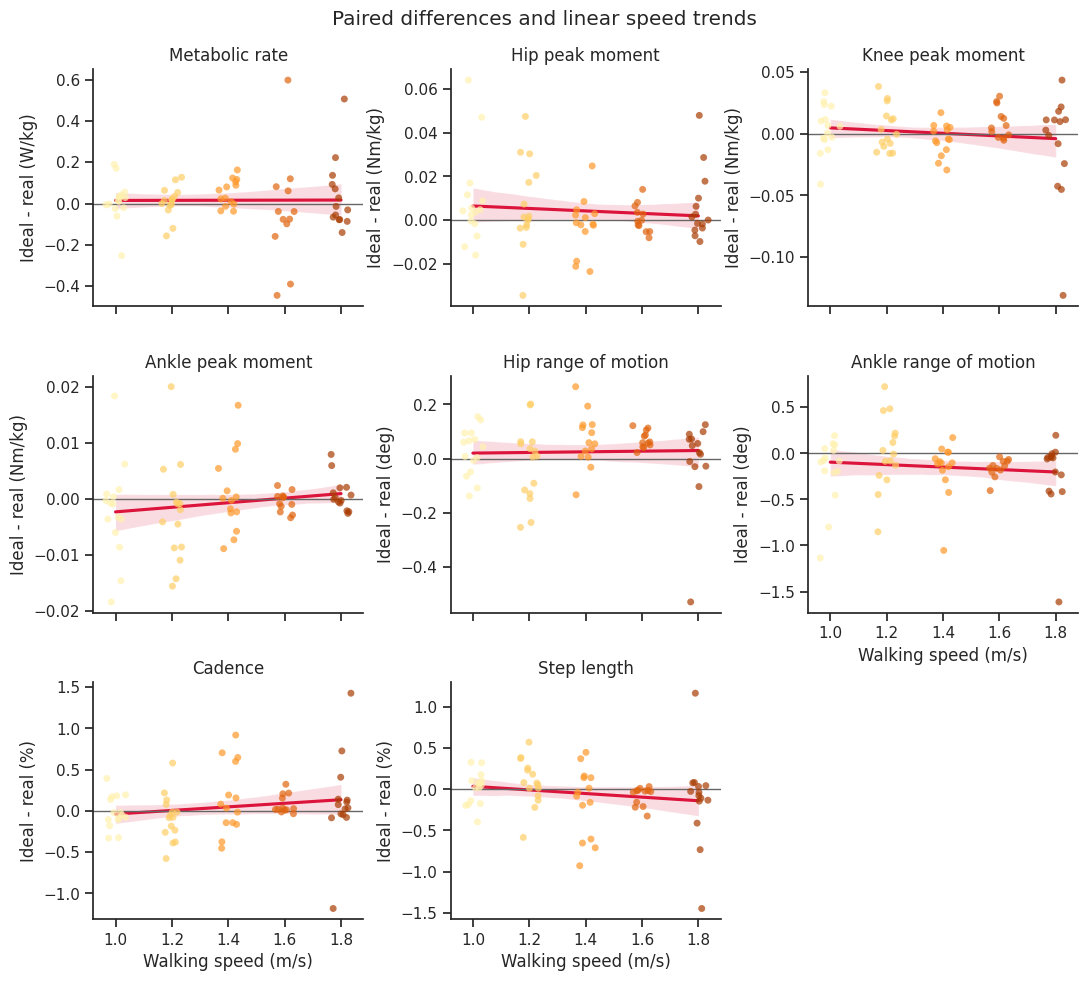

In [10]:
def difference_grid(kind, title):
    fig, axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
    for ax, (metric, panel_title, ylabel) in zip(axes.flat, difference_specs):
        plot_data = paired_df[paired_df["metric"] == metric]
        common = dict(
            data=plot_data, x="speed", y="difference", hue="speed",
            order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
            legend=False, ax=ax,
        )
        if kind == "box":
            sns.boxplot(**common, showfliers=True)
        else:
            sns.violinplot(**common, inner="quart", cut=0, density_norm="width")
            sns.stripplot(
                data=points_within_boxplot_whiskers(plot_data, "difference", ["speed"]), x="speed", y="difference", hue="speed",
                order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
                jitter=0.14, size=5, alpha=0.9,
                edgecolor="0.15", linewidth=0.7, legend=False, zorder=6, ax=ax,
            )
            medians = plot_data.groupby("speed")["difference"].median().reindex(SPEEDS)
            ax.plot(
                range(len(SPEEDS)), medians, color="0.15",
                marker="o", linewidth=2, markersize=5, zorder=5,
            )
        ax.axhline(0, color="0.4", linewidth=1)
        ax.set(title=panel_title, xlabel="Walking speed (m/s)", ylabel=ylabel)
    axes.flat[-1].axis("off")
    fig.suptitle(title)
    sns.despine(fig=fig)
    return fig

fig_difference_box = difference_grid(
    "box", "Paired discrete-metric differences: boxplots",
)
fig_difference_violin = difference_grid(
    "violin", "Paired discrete-metric differences: violin plots",
)

# Connect the same participant across walking speeds.
fig_connected, connected_axes = plt.subplots(3, 3, figsize=(13, 10), constrained_layout=True)
for ax, (metric, title, ylabel) in zip(connected_axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.lineplot(
        data=points_within_boxplot_whiskers(plot_data, "difference", ["speed"]), x="speed", y="difference",
        units="participant", estimator=None, marker="o",
        color="0.35", alpha=0.55, linewidth=1, ax=ax,
    )
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set_xticks(SPEEDS)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)
connected_axes.flat[-1].axis("off")
fig_connected.suptitle("Participant-level paired differences across walking speeds")
sns.despine(fig=fig_connected)

# Categorical points with an overlaid linear speed trend.
metric_order = [metric for metric, _, _ in difference_specs]
cat_grid = sns.catplot(
    data=paired_df, x="speed", y="difference", col="metric",
    col_order=metric_order, col_wrap=3, kind="strip",
    hue="speed", order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
    jitter=0.18, alpha=0.7, height=3.2, aspect=1.15,
    sharey=False, legend=False,
)
for ax, (metric, title, ylabel) in zip(cat_grid.axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.regplot(
        data=plot_data, x="speed_position", y="difference",
        scatter=False, color="crimson", ci=95, truncate=True, ax=ax,
    )
    ax.axhline(0, color="0.4", linewidth=1)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)
cat_grid.figure.suptitle("Paired differences and linear speed trends", y=1.02)
sns.despine(fig=cat_grid.figure)
plt.show()

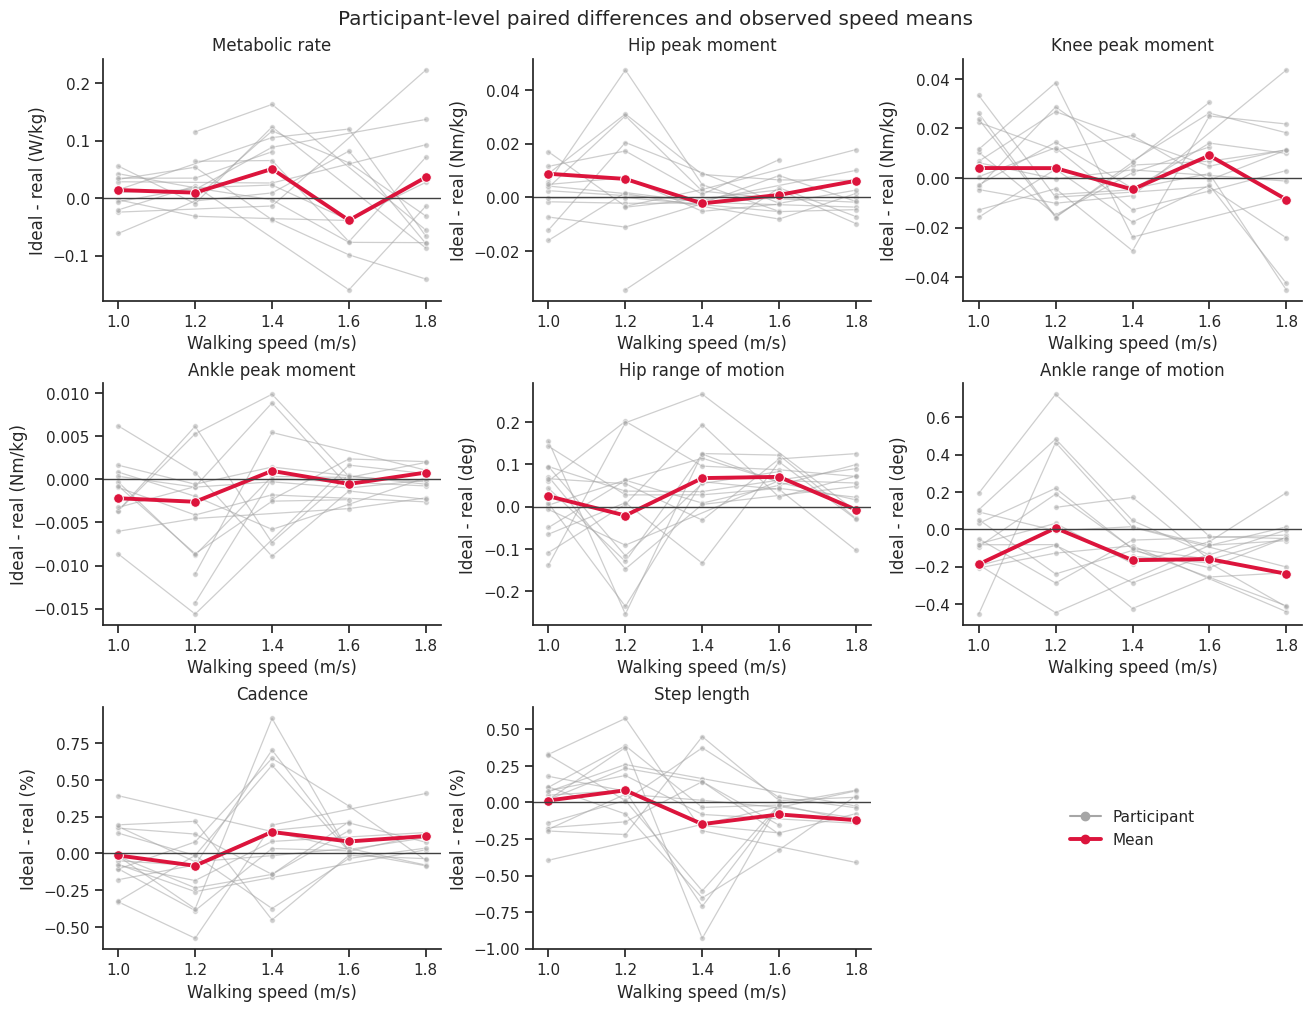

In [11]:
# Participant-specific changes and the observed mean at each speed.
fig_participant_trends, trend_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (metric, title, ylabel) in zip(trend_axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.lineplot(
        data=points_within_boxplot_whiskers(plot_data, "difference", ["speed"]), x="speed", y="difference",
        units="participant", estimator=None, marker="o",
        color="0.65", alpha=0.55, linewidth=0.9, markersize=4, ax=ax,
    )
    sns.lineplot(
        data=plot_data, x="speed", y="difference",
        estimator="mean", errorbar=None, marker="o",
        color="crimson", linewidth=2.8, markersize=7, ax=ax,
    )
    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_xticks(SPEEDS)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)

trend_axes.flat[-1].axis("off")
trend_axes.flat[-1].plot([], [], color="0.65", marker="o", label="Participant")
trend_axes.flat[-1].plot(
    [], [], color="crimson", marker="o", linewidth=2.8, label="Mean",
)
trend_axes.flat[-1].legend(loc="center", frameon=False)
fig_participant_trends.suptitle(
    "Participant-level paired differences and observed speed means"
)
sns.despine(fig=fig_participant_trends)
plt.show()

,metric,term,estimate,standard_error,p_value
0,metabolic_rate_w_per_kg,Intercept,3.798062,0.152455,5.421991e-137
1,metabolic_rate_w_per_kg,"C(treadmill_model, Treatment(reference='real')...",0.257494,0.214082,2.290593e-01
2,metabolic_rate_w_per_kg,speed_c,4.156902,0.533444,6.566105e-15
3,metabolic_rate_w_per_kg,"speed_c:C(treadmill_model, Treatment(reference...",0.546440,0.753045,4.680586e-01
4,hip_peak_moment,Intercept,-0.328427,0.009994,7.683714e-237
5,hip_peak_moment,"C(treadmill_model, Treatment(reference='real')...",0.002619,0.009167,7.751367e-01
6,hip_peak_moment,speed_c,-0.344995,0.022890,2.487294e-51
7,hip_peak_moment,"speed_c:C(treadmill_model, Treatment(reference...",-0.005735,0.032258,8.588921e-01
8,knee_peak_moment,Intercept,0.390536,0.027208,1.008719e-46
9,knee_peak_moment,"C(treadmill_model, Treatment(reference='real')...",-0.000867,0.013478,9.486997e-01


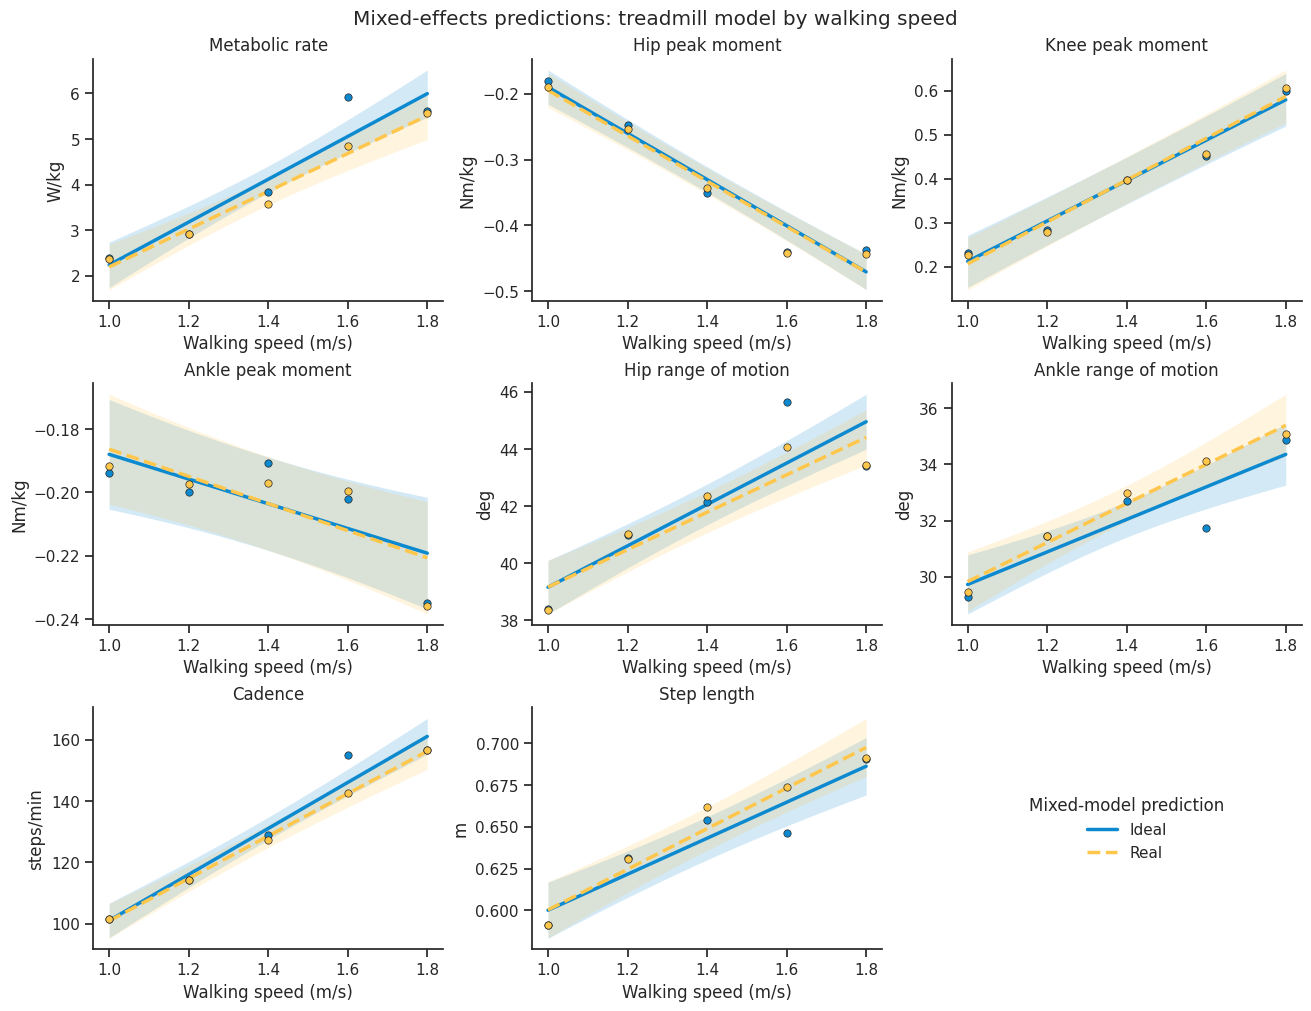

In [12]:
# Final mixed-effects result: predicted ideal and real trends.
from IPython.display import display
display(mixed_effects_table)

fig_mixed_predictions_final, prediction_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (column, title, ylabel) in zip(prediction_axes.flat, metric_specs):
    predictions = mixed_model_predictions[column]
    for model, linestyle in [("ideal", "-"), ("real", "--")]:
        model_predictions = predictions[predictions["treadmill_model"] == model]
        color = model_palette[model]
        ax.plot(
            model_predictions["speed"], model_predictions["predicted"],
            color=color, linestyle=linestyle, linewidth=2.5, label=model.title(),
        )
        ax.fill_between(
            model_predictions["speed"], model_predictions["lower"], model_predictions["upper"],
            color=color, alpha=0.18, linewidth=0,
        )
        observed = metrics_df[metrics_df["treadmill_model"] == model]
        observed_means = observed.groupby("speed")[column].mean().reindex(SPEEDS)
        ax.scatter(
            SPEEDS, observed_means, color=color, edgecolor="0.15",
            linewidth=0.5, s=28, zorder=5,
        )
    ax.set_xticks(SPEEDS)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)

prediction_axes.flat[-1].axis("off")
prediction_axes.flat[-1].plot([], [], color=model_palette["ideal"], linewidth=2.5, label="Ideal")
prediction_axes.flat[-1].plot(
    [], [], color=model_palette["real"], linestyle="--", linewidth=2.5, label="Real",
)
prediction_axes.flat[-1].legend(title="Mixed-model prediction", loc="center", frameon=False)
fig_mixed_predictions_final.suptitle(
    "Mixed-effects predictions: treadmill model by walking speed"
)
sns.despine(fig=fig_mixed_predictions_final)
plt.show()

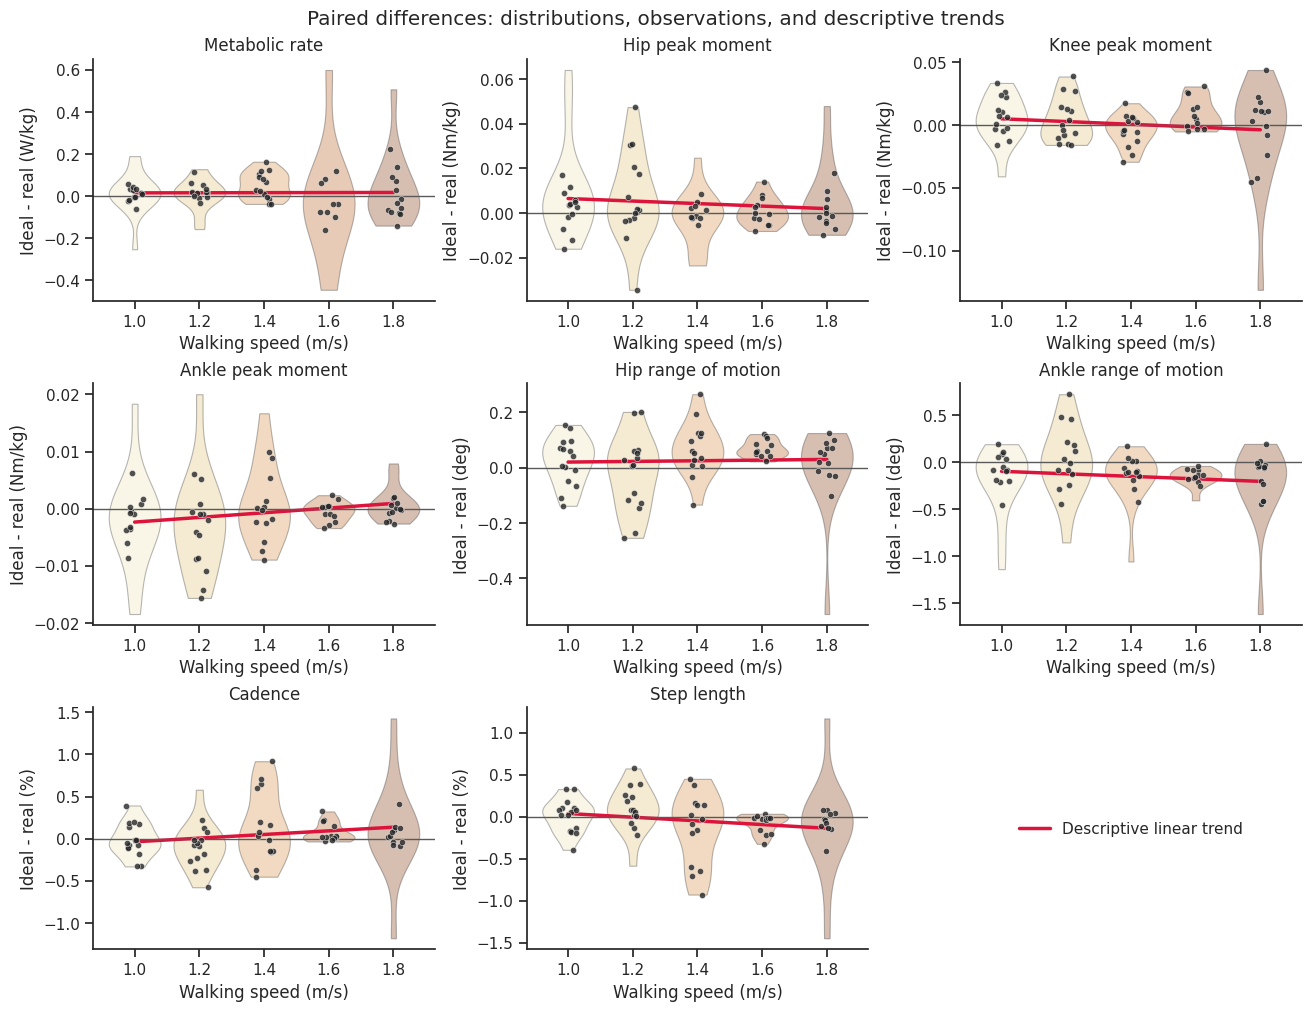

In [13]:
# Final exploratory figure: distributions, observations, and one descriptive trend.
fig_violin_trend, violin_trend_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (metric, title, ylabel) in zip(violin_trend_axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.violinplot(
        data=plot_data, x="speed", y="difference", hue="speed",
        order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
        inner=None, cut=0, density_norm="width", linewidth=0.8,
        saturation=0.65, alpha=0.35, legend=False, ax=ax,
    )
    sns.stripplot(
        data=points_within_boxplot_whiskers(plot_data, "difference", ["speed"]), x="speed", y="difference",
        order=SPEEDS, jitter=0.14, color="0.15",
        size=4.5, alpha=0.8, edgecolor="white", linewidth=0.4,
        zorder=5, ax=ax,
    )
    sns.regplot(
        data=plot_data, x="speed_position", y="difference",
        scatter=False, ci=None, truncate=True,
        color="crimson", line_kws={"linewidth": 2.5}, ax=ax,
    )
    ax.axhline(0, color="0.35", linewidth=1)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)

violin_trend_axes.flat[-1].axis("off")
violin_trend_axes.flat[-1].plot(
    [], [], color="crimson", linewidth=2.5, label="Descriptive linear trend",
)
violin_trend_axes.flat[-1].legend(loc="center", frameon=False)
fig_violin_trend.suptitle(
    "Paired differences: distributions, observations, and descriptive trends"
)
sns.despine(fig=fig_violin_trend)
plt.show()

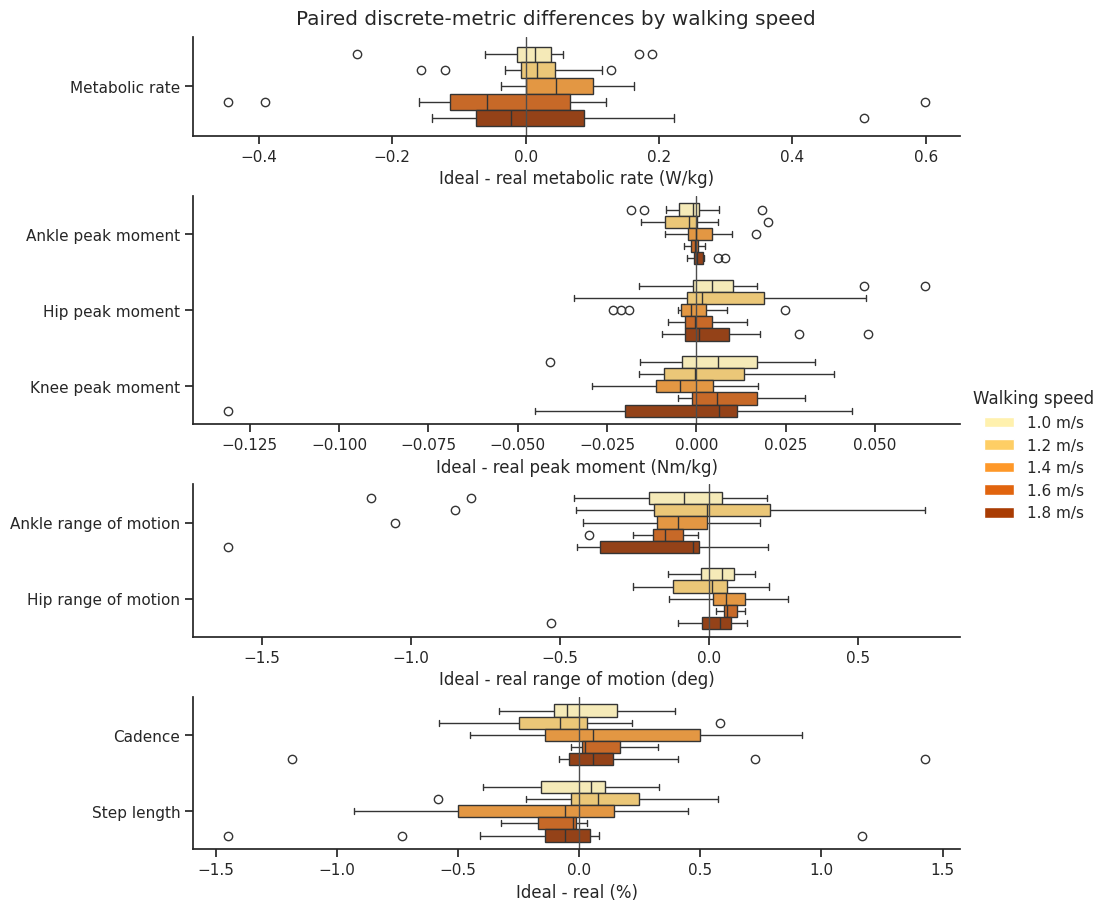

In [14]:
# Paper-style difference boxplots with walking speed as hue.
metric_groups = [
    (["metabolic_rate_w_per_kg"], "Ideal - real metabolic rate (W/kg)"),
    (["hip_peak_moment", "knee_peak_moment", "ankle_peak_moment"], "Ideal - real peak moment (Nm/kg)"),
    (["hip_rom", "ankle_rom"], "Ideal - real range of motion (deg)"),
    (["cadence_steps_per_min", "step_length_m"], "Ideal - real (%)"),
]
metric_labels = {metric: title for metric, title, _ in difference_specs}
fig_speed_box, speed_box_axes = plt.subplots(
    4, 1, figsize=(11, 9), constrained_layout=True,
    gridspec_kw={"height_ratios": [1.3, 3, 2, 2]},
)
for ax, (metrics, xlabel) in zip(speed_box_axes, metric_groups):
    plot_data = paired_df[paired_df["metric"].isin(metrics)].copy()
    plot_data["metric_label"] = plot_data["metric"].map(metric_labels)
    sns.boxplot(
        data=plot_data, y="metric_label", x="difference", hue="speed",
        hue_order=SPEEDS, palette=speed_palette, dodge=True,
        showfliers=True, ax=ax,
    )
    ax.axvline(0, color="0.3", linewidth=1)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    if ax.get_legend() is not None:
        ax.get_legend().remove()

speed_handles = [
    Patch(facecolor=speed_palette[speed], label=f"{speed:.1f} m/s")
    for speed in SPEEDS
]
fig_speed_box.legend(
    handles=speed_handles, title="Walking speed",
    loc="outside right center", frameon=False,
)
fig_speed_box.suptitle("Paired discrete-metric differences by walking speed")
sns.despine(fig=fig_speed_box)
plt.show()

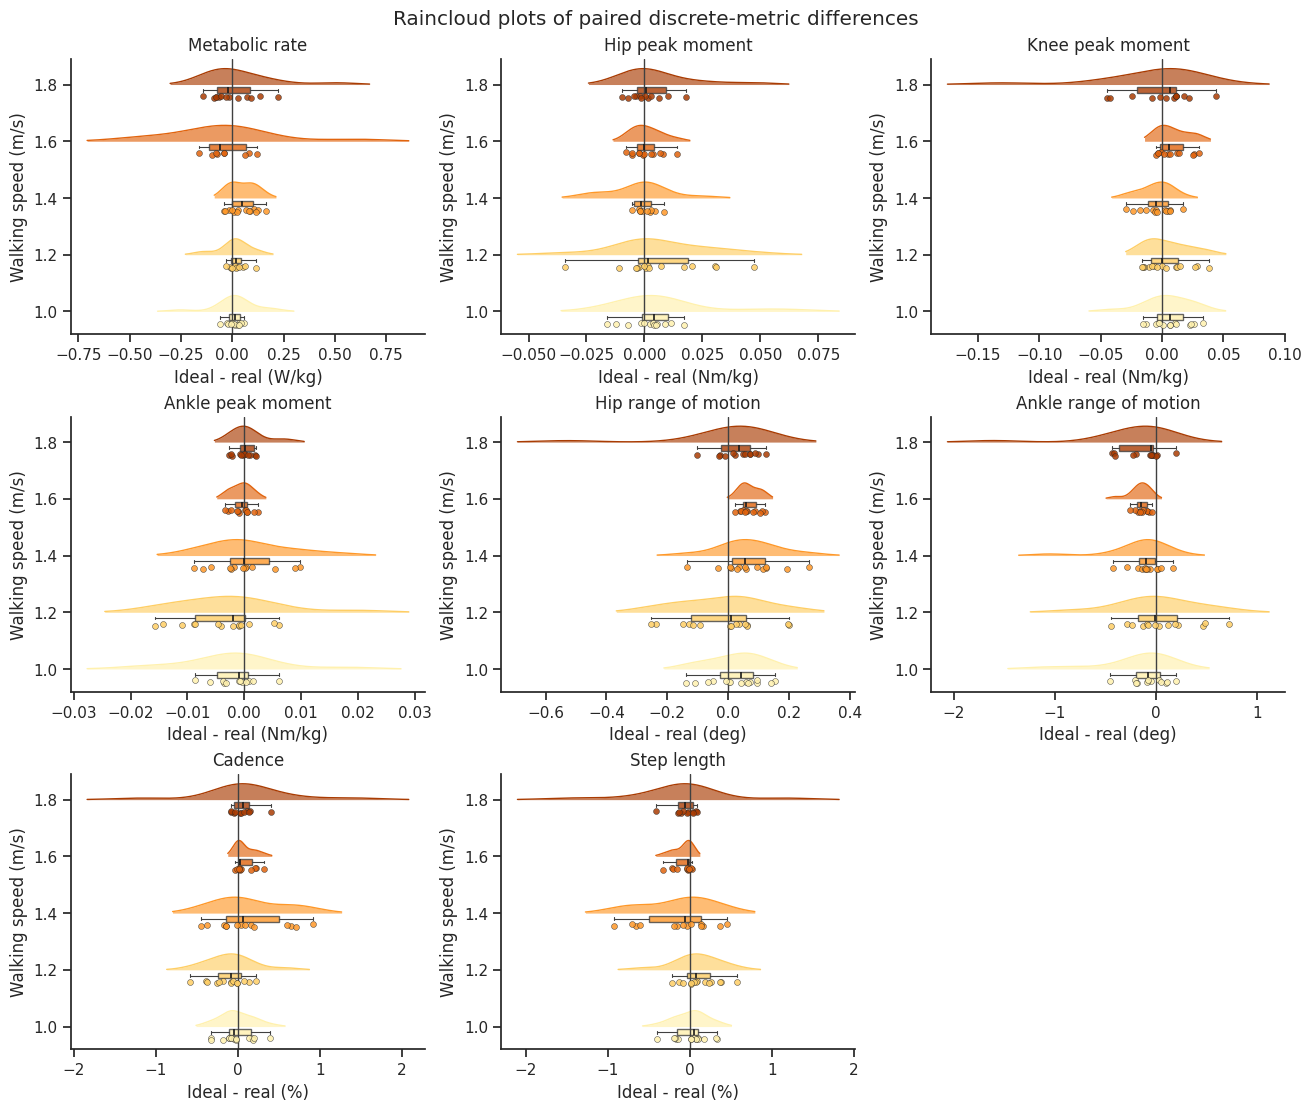

In [15]:
# Horizontal rainclouds of paired ideal - real differences.
import numpy as np
from scipy.stats import gaussian_kde

fig_raincloud, raincloud_axes = plt.subplots(
    3, 3, figsize=(13, 11), constrained_layout=True,
)
rng = np.random.default_rng(7)
for ax, (metric, title, xlabel) in zip(raincloud_axes.flat, difference_specs):
    metric_data = paired_df[paired_df["metric"] == metric]
    for position, speed in enumerate(SPEEDS):
        values = metric_data.loc[metric_data["speed"] == speed, "difference"].dropna().to_numpy()
        color = speed_palette[speed]

        # Half-density above the speed baseline.
        if len(values) > 1 and np.ptp(values) > 0:
            padding = max(np.ptp(values) * 0.25, abs(values).max() * 0.03, 1e-9)
            density_x = np.linspace(values.min() - padding, values.max() + padding, 200)
            density = gaussian_kde(values)(density_x)
            density = density / density.max() * 0.28
            ax.fill_between(
                density_x, position, position + density,
                color=color, alpha=0.65, linewidth=0,
            )
            ax.plot(density_x, position + density, color=color, linewidth=1)

        # Compact box below the baseline.
        box = ax.boxplot(
            values, positions=[position - 0.10], vert=False, widths=0.10,
            patch_artist=True, showfliers=False, manage_ticks=False,
            medianprops={"color": "0.1", "linewidth": 1.2},
            whiskerprops={"color": "0.25", "linewidth": 0.8},
            capprops={"color": "0.25", "linewidth": 0.8},
            boxprops={"facecolor": color, "edgecolor": "0.25", "alpha": 0.8},
        )

        # Only the markers are limited to the standard boxplot whiskers.
        # The density and box summary above still use every observation.
        q1, q3 = np.quantile(values, [0.25, 0.75])
        iqr = q3 - q1
        visible_values = values[(values >= q1 - 1.5 * iqr) & (values <= q3 + 1.5 * iqr)]
        point_y = position - 0.22 + rng.uniform(-0.025, 0.025, len(visible_values))
        ax.scatter(
            visible_values, point_y, s=18, color=color, edgecolor="0.15",
            linewidth=0.35, alpha=0.85, zorder=4,
        )

    ax.axvline(0, color="0.25", linewidth=1)
    ax.set_yticks(range(len(SPEEDS)), [f"{speed:.1f}" for speed in SPEEDS])
    ax.set_ylim(-0.4, len(SPEEDS) - 0.55)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Walking speed (m/s)")

raincloud_axes.flat[-1].axis("off")
fig_raincloud.suptitle("Raincloud plots of paired discrete-metric differences")
sns.despine(fig=fig_raincloud)
plt.show()

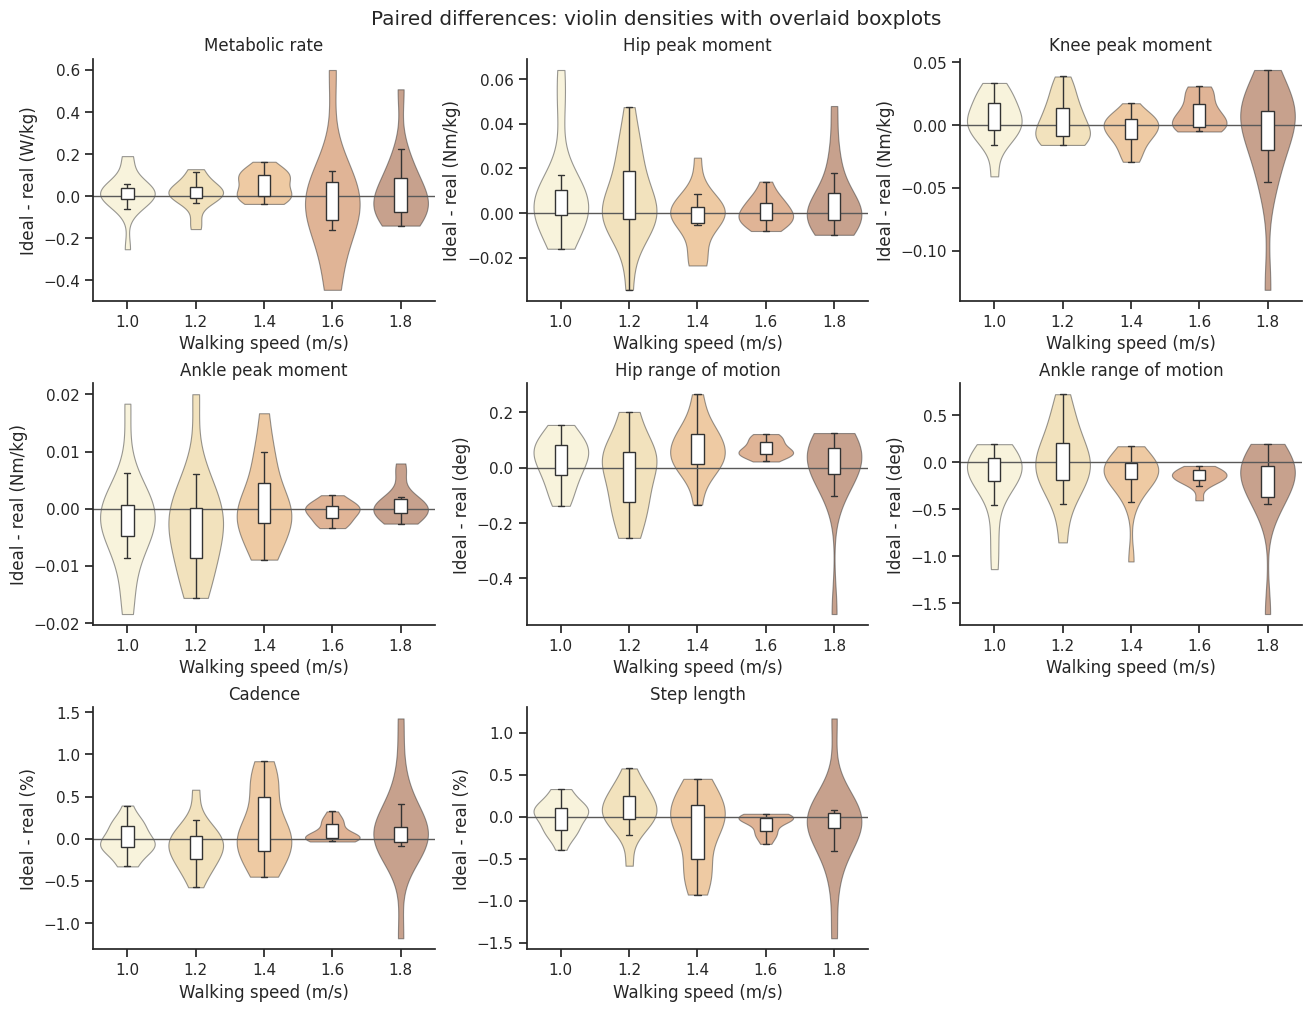

In [16]:
# Violin densities with narrow boxplots overlaid.
fig_violin_box, violin_box_axes = plt.subplots(
    3, 3, figsize=(13, 10), constrained_layout=True,
)
for ax, (metric, title, ylabel) in zip(violin_box_axes.flat, difference_specs):
    plot_data = paired_df[paired_df["metric"] == metric]
    sns.violinplot(
        data=plot_data, x="speed", y="difference", hue="speed",
        order=SPEEDS, hue_order=SPEEDS, palette=speed_palette,
        inner=None, cut=0, density_norm="width",
        linewidth=0.8, saturation=0.7, alpha=0.5, legend=False, ax=ax,
    )
    sns.boxplot(
        data=plot_data, x="speed", y="difference",
        order=SPEEDS, width=0.18, showfliers=False,
        boxprops={"facecolor": "white", "edgecolor": "0.2", "zorder": 4},
        whiskerprops={"color": "0.2", "linewidth": 1},
        capprops={"color": "0.2", "linewidth": 1},
        medianprops={"color": "crimson", "linewidth": 1.8},
        ax=ax,
    )
    ax.axhline(0, color="0.35", linewidth=1)
    ax.set(title=title, xlabel="Walking speed (m/s)", ylabel=ylabel)

violin_box_axes.flat[-1].axis("off")
fig_violin_box.suptitle("Paired differences: violin densities with overlaid boxplots")
sns.despine(fig=fig_violin_box)
plt.show()

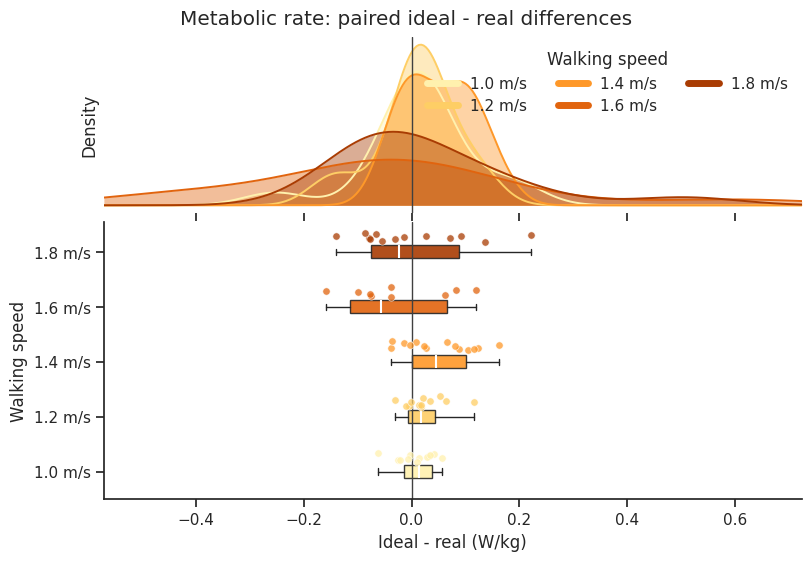

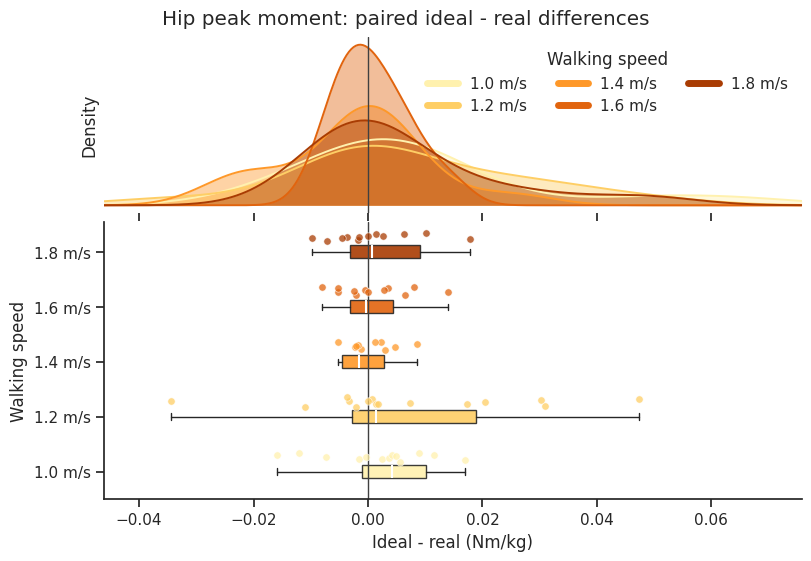

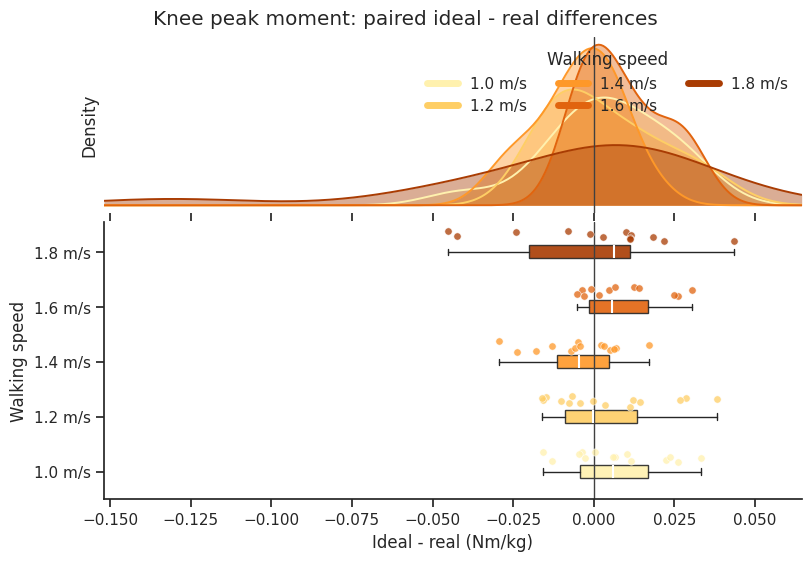

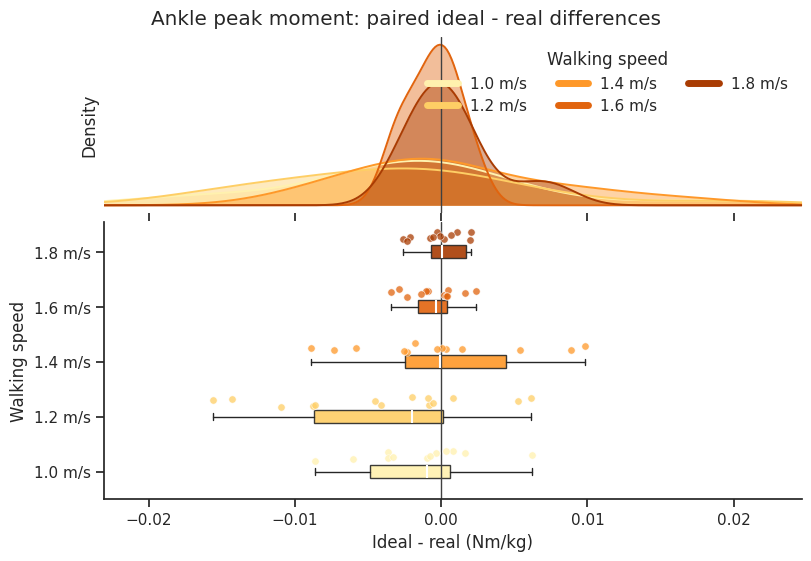

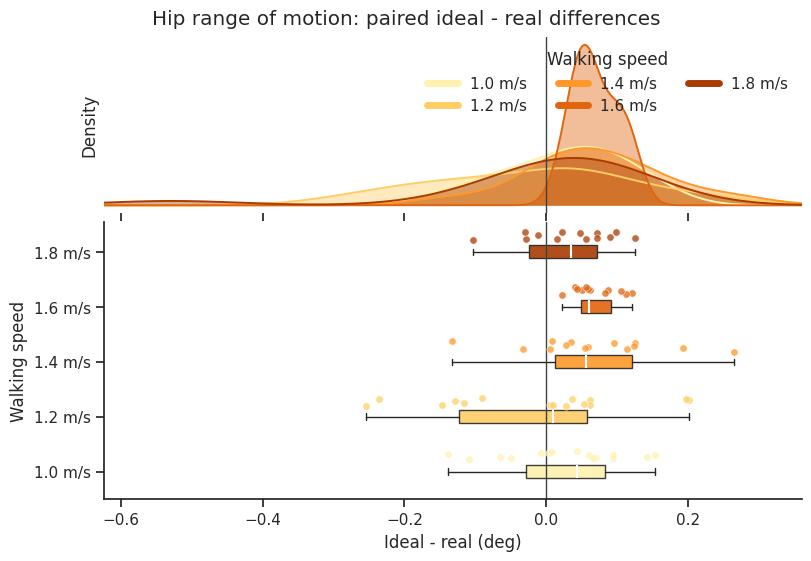

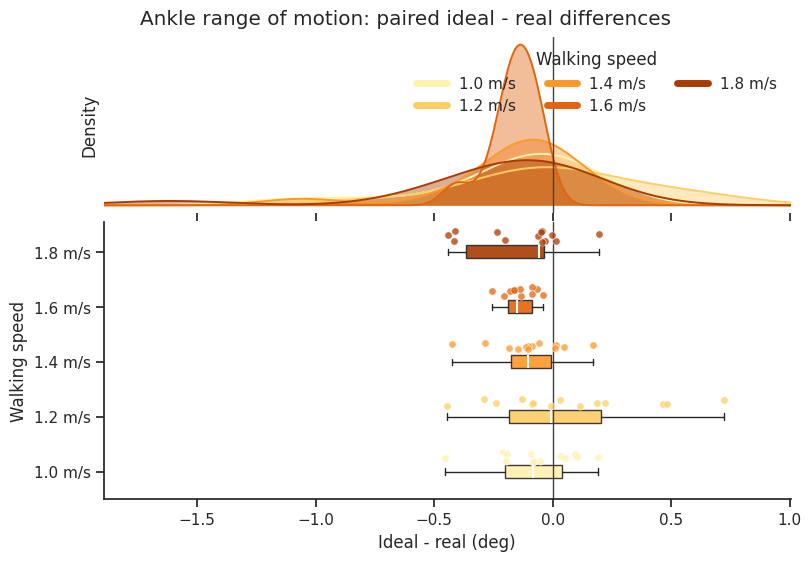

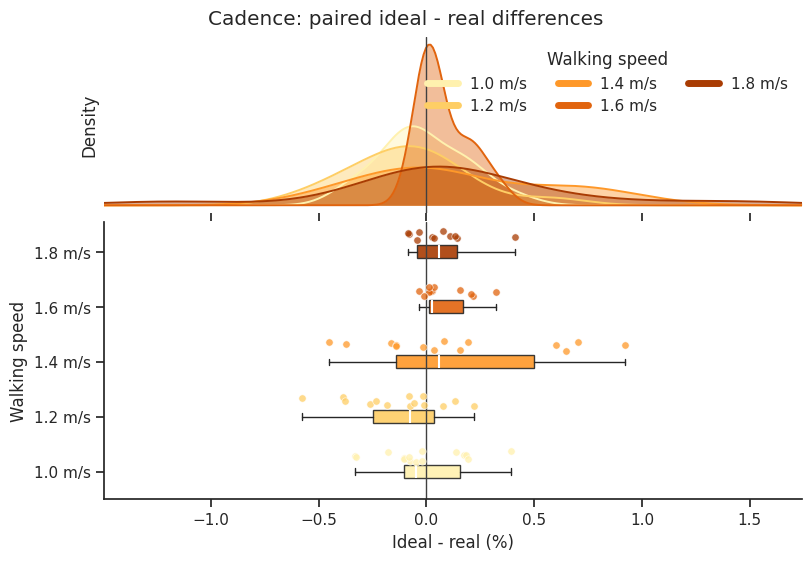

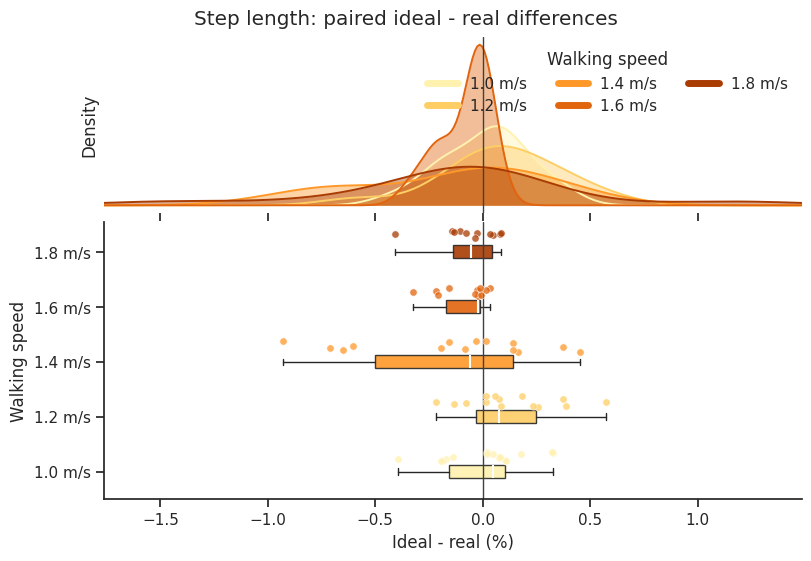

In [17]:
# Deneb-inspired raincloud: one figure per metric.
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

deneb_raincloud_figures = {}
rng = np.random.default_rng(17)
for metric, title, xlabel in difference_specs:
    metric_data = paired_df[paired_df["metric"] == metric]
    all_values = metric_data["difference"].dropna().to_numpy()
    padding = max(np.ptp(all_values) * 0.12, abs(all_values).max() * 0.03, 1e-9)
    x_min = min(all_values.min() - padding, 0)
    x_max = max(all_values.max() + padding, 0)
    density_x = np.linspace(x_min, x_max, 300)

    fig_metric = plt.figure(figsize=(8, 5.5), constrained_layout=True)
    grid = fig_metric.add_gridspec(2, 1, height_ratios=[1.4, 2.2], hspace=0.03)
    density_axis = fig_metric.add_subplot(grid[0])
    rain_axis = fig_metric.add_subplot(grid[1], sharex=density_axis)

    # Overlay the five speed-specific densities in the top panel.
    for speed in SPEEDS:
        values = metric_data.loc[metric_data["speed"] == speed, "difference"].dropna().to_numpy()
        color = speed_palette[speed]
        if len(values) > 1 and np.ptp(values) > 0:
            density = gaussian_kde(values)(density_x)
            density_axis.fill_between(
                density_x, 0, density, color=color, alpha=0.42, linewidth=0,
            )
            density_axis.plot(density_x, density, color=color, linewidth=1.4)

    density_axis.axvline(0, color="0.25", linewidth=1)
    density_axis.set_ylabel("Density")
    density_axis.tick_params(axis="x", labelbottom=False)
    density_axis.set_yticks([])

    # Boxplots and raw participant observations in one row per speed.
    for position, speed in enumerate(SPEEDS):
        values = metric_data.loc[metric_data["speed"] == speed, "difference"].dropna().to_numpy()
        color = speed_palette[speed]
        rain_axis.boxplot(
            values, positions=[position], vert=False, widths=0.24,
            patch_artist=True, showfliers=False, manage_ticks=False,
            medianprops={"color": "white", "linewidth": 1.5},
            whiskerprops={"color": "0.15", "linewidth": 1},
            capprops={"color": "0.15", "linewidth": 1},
            boxprops={"facecolor": color, "edgecolor": "0.15", "alpha": 0.9},
        )
        # Only the markers are limited to the standard boxplot whiskers.
        # The density and box summary above still use every observation.
        q1, q3 = np.quantile(values, [0.25, 0.75])
        iqr = q3 - q1
        visible_values = values[(values >= q1 - 1.5 * iqr) & (values <= q3 + 1.5 * iqr)]
        point_y = position + rng.uniform(0.18, 0.38, len(visible_values))
        rain_axis.scatter(
            visible_values, point_y, color=color, s=28, alpha=0.75,
            edgecolor="white", linewidth=0.5, zorder=4,
        )

    rain_axis.axvline(0, color="0.25", linewidth=1)
    rain_axis.set_xlim(x_min, x_max)
    rain_axis.set_ylim(-0.5, len(SPEEDS) - 0.45)
    rain_axis.set_yticks(range(len(SPEEDS)), [f"{speed:.1f} m/s" for speed in SPEEDS])
    rain_axis.set_xlabel(xlabel)
    rain_axis.set_ylabel("Walking speed")

    legend_handles = [
        Line2D([0], [0], color=speed_palette[speed], linewidth=5, label=f"{speed:.1f} m/s")
        for speed in SPEEDS
    ]
    density_axis.legend(
        handles=legend_handles, title="Walking speed",
        loc="upper right", frameon=False, ncol=3,
    )
    fig_metric.suptitle(f"{title}: paired ideal - real differences")
    sns.despine(ax=density_axis, left=True, bottom=True)
    sns.despine(ax=rain_axis)
    deneb_raincloud_figures[metric] = fig_metric

plt.show()

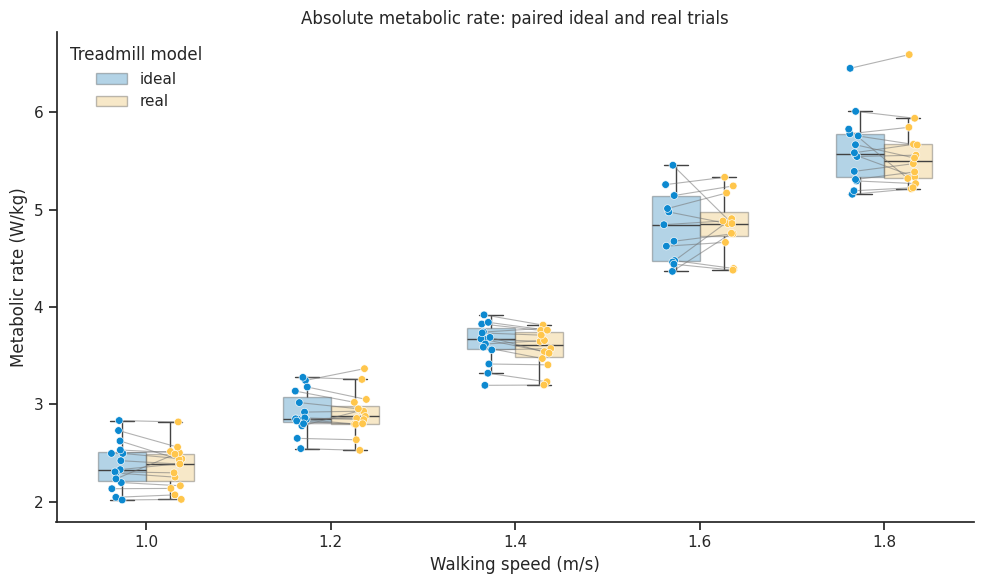

In [18]:
# Absolute metabolic rate with participant-level ideal-real pairing
metabolic_column = "metabolic_rate_w_per_kg"
metabolic_data = metrics_df[["participant", "speed", "treadmill_model", metabolic_column]].dropna()
paired_metabolic = (
    metabolic_data.pivot_table(
        index=["participant", "speed"],
        columns="treadmill_model",
        values=metabolic_column,
        aggfunc="first",
    )
    .dropna(subset=["ideal", "real"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=metabolic_data, x="speed", y=metabolic_column,
    hue="treadmill_model", order=SPEEDS, hue_order=model_order,
    palette=model_palette, width=0.52, showfliers=False,
    boxprops={"alpha": 0.35}, ax=ax,
)

model_offsets = {"ideal": -0.16, "real": 0.16}
rng = np.random.default_rng(42)
for speed_position, speed in enumerate(SPEEDS):
    speed_pairs = paired_metabolic[paired_metabolic["speed"] == speed]
    participant_jitter = rng.uniform(-0.035, 0.035, len(speed_pairs))
    for jitter, (_, pair) in zip(participant_jitter, speed_pairs.iterrows()):
        x_ideal = speed_position + model_offsets["ideal"] + jitter
        x_real = speed_position + model_offsets["real"] + jitter
        ax.plot(
            [x_ideal, x_real], [pair["ideal"], pair["real"]],
            color="0.45", linewidth=0.8, alpha=0.55, zorder=3,
        )
        ax.scatter(
            [x_ideal, x_real], [pair["ideal"], pair["real"]],
            color=[model_palette["ideal"], model_palette["real"]],
            s=30, edgecolor="white", linewidth=0.45, zorder=4,
        )

ax.set_xlabel("Walking speed (m/s)")
ax.set_ylabel("Metabolic rate (W/kg)")
ax.set_title("Absolute metabolic rate: paired ideal and real trials")
ax.legend(title="Treadmill model", frameon=False)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

## Discrete-metric differences versus participant anthropometrics

Each point is one participant-speed pair. Colors identify walking speed, and the plotted outcome is the paired ideal-minus-real difference.

In [19]:
anthropometric_columns = ["body_mass_kg", "height_m", "bmi_kg_per_m2"]
missing_anthropometrics = [column for column in anthropometric_columns if column not in df.columns]
if missing_anthropometrics:
    raise KeyError(f"Trajectory export is missing anthropometric columns: {missing_anthropometrics}")

anthropometrics = (
    df.reset_index()
    .groupby("participant", as_index=False)[anthropometric_columns]
    .first()
)
anthropometric_difference_data = paired_df.merge(
    anthropometrics, on="participant", how="left", validate="many_to_one",
)
anthropometric_axes = [
    ("body_mass_kg", "Body mass (kg)"),
    ("height_m", "Height (m)"),
    ("bmi_kg_per_m2", "BMI (kg/m²)"),
]
metric_titles = {metric: title for metric, title, _ in difference_specs}
metric_ylabels = {metric: ylabel for metric, _, ylabel in difference_specs}
anthropometric_difference_data.head()

,participant,speed,metric,ideal,real,difference,speed_position,body_mass_kg,height_m,bmi_kg_per_m2
0,P1,1.0,ankle_peak_moment,-0.205579,-0.205252,-0.000327,0,68.24,1.78,21.537685
1,P1,1.0,ankle_rom,30.546865,30.624928,-0.078063,0,68.24,1.78,21.537685
2,P1,1.0,cadence_steps_per_min,99.719837,99.823570,-0.104025,0,68.24,1.78,21.537685
3,P1,1.0,hip_peak_moment,-0.201817,-0.207437,0.005620,0,68.24,1.78,21.537685
4,P1,1.0,hip_rom,38.247883,38.244289,0.003594,0,68.24,1.78,21.537685


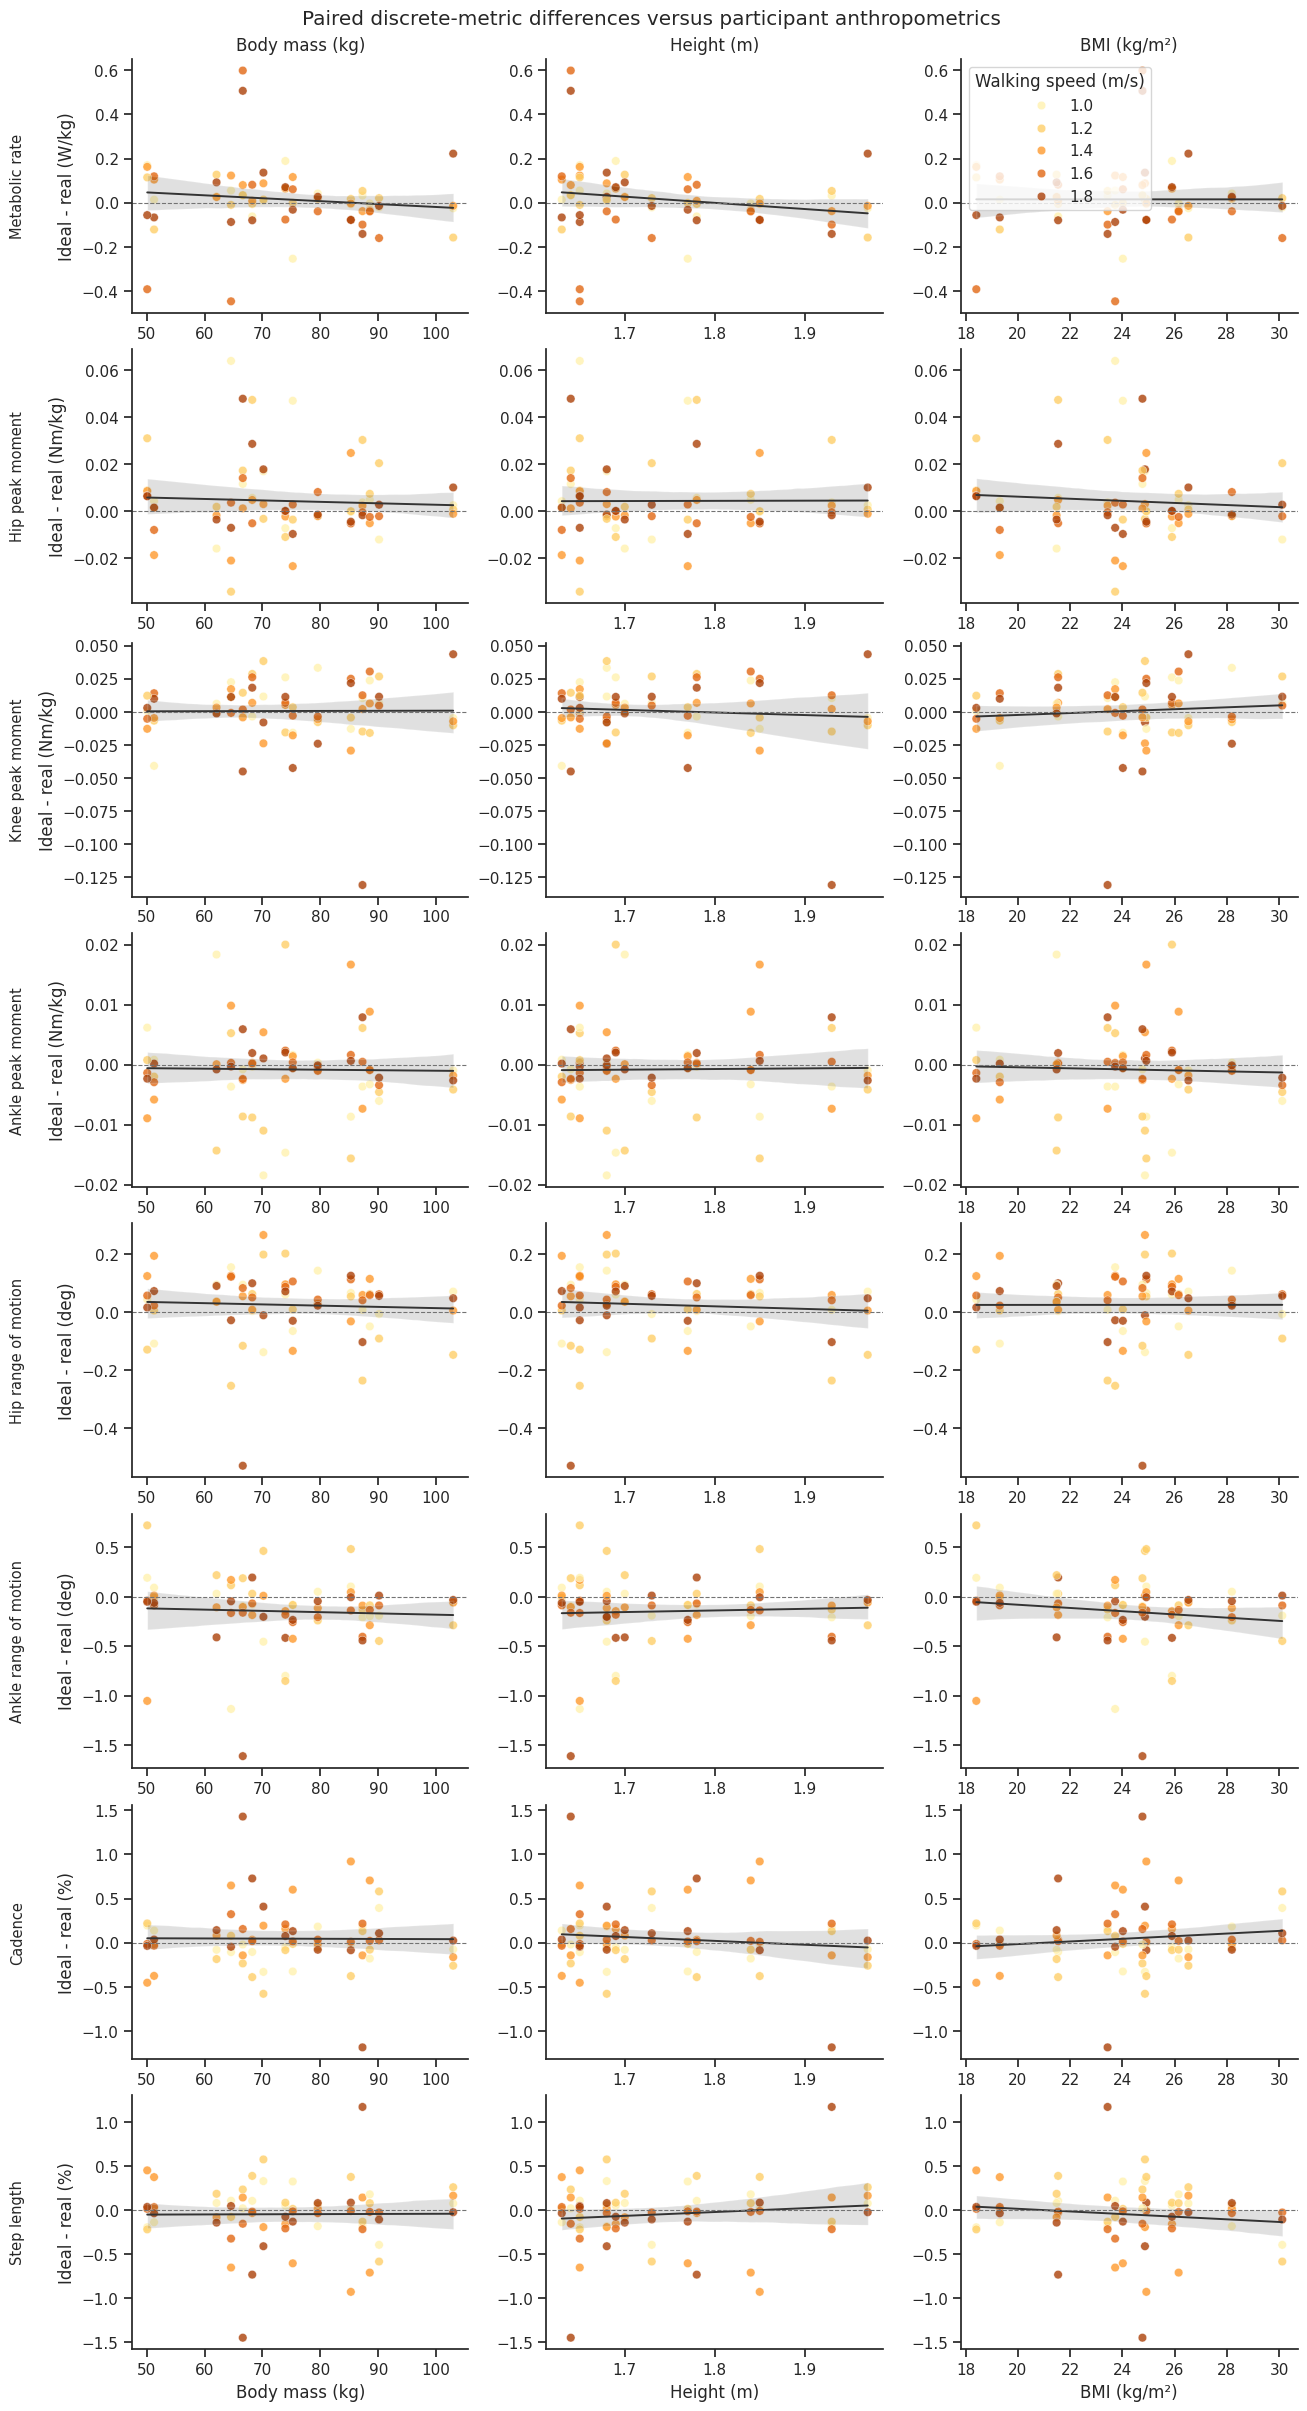

In [20]:
fig_anthropometrics, axes_anthropometrics = plt.subplots(
    len(difference_specs), len(anthropometric_axes),
    figsize=(13, 24), constrained_layout=True,
)

for row, (metric, metric_title, ylabel) in enumerate(difference_specs):
    metric_data = anthropometric_difference_data[
        anthropometric_difference_data["metric"] == metric
    ]
    for column, (anthropometric_column, anthropometric_label) in enumerate(anthropometric_axes):
        ax = axes_anthropometrics[row, column]
        sns.scatterplot(
            data=metric_data,
            x=anthropometric_column,
            y="difference",
            hue="speed",
            hue_order=SPEEDS,
            palette=speed_palette,
            s=38,
            alpha=0.78,
            edgecolor="white",
            linewidth=0.35,
            legend=(row == 0 and column == 2),
            ax=ax,
        )
        sns.regplot(
            data=metric_data,
            x=anthropometric_column,
            y="difference",
            scatter=False,
            ci=95,
            color="0.2",
            line_kws={"linewidth": 1.4},
            ax=ax,
        )
        ax.axhline(0, color="0.45", linewidth=0.8, linestyle="--")
        ax.set_xlabel(anthropometric_label if row == len(difference_specs) - 1 else "")
        ax.set_ylabel(ylabel if column == 0 else "")
        if row == 0:
            ax.set_title(anthropometric_label)
        if column == 0:
            ax.text(
                -0.34, 0.5, metric_title, transform=ax.transAxes,
                rotation=90, va="center", ha="center", fontsize=10.5,
            )

legend = axes_anthropometrics[0, 2].get_legend()
if legend is not None:
    legend.set_title("Walking speed (m/s)")
fig_anthropometrics.suptitle(
    "Paired discrete-metric differences versus participant anthropometrics"
)
sns.despine(fig=fig_anthropometrics)

if EXPORT_FIGURE:
    anthropometric_output = output_directory / f"discrete_metrics_vs_anthropometrics_{result_name}.pdf"
    fig_anthropometrics.savefig(anthropometric_output, bbox_inches="tight")
    print(f"Saved {anthropometric_output}")

plt.show()